In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as ui

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** DROPNANS Prep'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# initialize DataFrame
df_new = pd.DataFrame(columns=['column'])

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/4CleanFull_Heart_Engineer.pkl")
df_label = pd.read_pickle("../Data/4CleanFull_Label_Engineer.pkl")
df_can = pd.read_pickle("../Data/4CleanFull_CAN_Engineer.pkl")
df_don = pd.read_pickle("../Data/4CleanFull_DON_Engineer.pkl")
df_both = pd.read_pickle("../Data/4CleanFull_BOTH_Engineer.pkl")
df_nominal = pd.read_pickle("../Data/4CleanFull_Nominal_Engineer.pkl")
df_ordinal = pd.read_pickle("../Data/4CleanFull_Ordinal_Engineer.pkl")
df_numeric = pd.read_pickle("../Data/4CleanFull_Numeric_Engineer.pkl")
df_new = pd.read_pickle("../Data/4CleanFull_New_Engineer.pkl")
df_drop = pd.read_pickle("../Data/4CleanFull_Drop_Engineer.pkl")
df_dict = pd.read_pickle("../Data/4CleanFull_Dictionary_Engineer.pkl")
df_object = pd.read_pickle("../Data/4CleanFull_Object_Engineer.pkl")
df_unknown = pd.read_pickle("../Data/4CleanFull_Unknown_Engineer.pkl")
df_date = pd.read_pickle("../Data/4Clean_Date_Engineer.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

### Feature Information

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"New Features: {df_new.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Dictionary Features: {df_object.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")

Heart Dataset Rows: 27,494 & Columns: 250
Label Features: 15
Candidate Features: 128
Donor Features: 90
Both Features: 22
Nominal Features: 177
Ordinal Features: 13
Numeric Features: 61
New Features: 22
Drop Features: 23
Dictionary Features: 0
Object Features: 0
Unknown Features: 0
Date Features: 0


### Remove Unwanted Label Features

In [4]:
# remove unwanted labels
# removeCols = df_label.column[~df_label.column.isin(['TransplantSurvivalDay', 'LengthOfStay', 'TransplantStatus', 'GraftLifeSpanDay','GraftStatus'])].to_list()
removeCols = df_label.column[~df_label.column.isin(['TransplantSurvivalDay', 'LengthOfStay'])].to_list()

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 13 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 1 row(s) from df_ordinal DataFrame.
Remove 10 row(s) from df_nominal DataFrame.
Remove 2 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['AcuteRejectionEpisode', 'AirwayDehiscencePostTransplant', 'DialysisPostDischarge', 'FunctionalStatusFollowUp', 'GraftFailStatus', 'GraftLifeSpanDay', 'GraftStatus', 'LastFollowupNumber', 'PacemakerPostTransplant', 'RecipientStatus', 'RejectionTreatmentWithinOneYear', 'StrokePostTransplant', 'TransplantStatus']

Total Row(s) & Column(s) Before Removing Column(s): 27,494 & columns: 250
Total Row(s) & Column(s) After Removing Column(s): 27,494 & columns: 237


### Candidate Survival Information

In [5]:
# total NaNs
print("Total NaNs for TransplantSurvivalDay: ", df.TransplantSurvivalDay.isna().sum())
print("Total NaNs for LengthOfStay: ", df.LengthOfStay.isna().sum())
# remove rows where TransplantSurvivalDay is NaN
# df = df.dropna(subset=['TransplantSurvivalDay'])
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

# copy 
df_orig = df.copy()

Total NaNs for TransplantSurvivalDay:  425
Total NaNs for LengthOfStay:  887
Heart Dataset Rows: 27,494 & Columns: 237


In [6]:
pd.DataFrame(df[['TransplantSurvivalDay','LengthOfStay']].describe()).T

,count,mean,std,min,25%,50%,75%,max
TransplantSurvivalDay,27069.0,1274.198012,1020.204697,0.0,364.0,1093.0,2058.0,3861.0
LengthOfStay,26607.0,22.548878,25.934613,0.0,11.0,16.0,24.0,823.0


In [7]:
# sanity check
uf.datatypeDF(df, display=True)

Total Data feature count:  237

Boolean feature count: 0
Category feature count: 77
Numeric feature count: 59
Object feature count: 101
Other feature count: 0

Total feature count:  237


### Review New Features

In [8]:
# remove all new features
print(sorted(df_new.column.to_list()))

['Age_Addition', 'Age_Difference', 'BMI_Addition', 'BMI_Difference', 'Creatinine_Addition_CAN', 'Creatinine_Difference_CAN', 'Creatinine_Mean_CAN', 'HeightCm_Addition', 'HeightCm_Difference', 'Hemodynamics_Addition_Mean_CAN', 'Hemodynamics_Interaction_Mean_CAN', 'Hemodynamics_Mean_CO_RT_CAN', 'Hemodynamics_Mean_PA_DIA_RT_CAN', 'Hemodynamics_Mean_PA_MN_RT_CAN', 'Hemodynamics_Mean_PCW_RT_CAN', 'Hemodynamics_Mean_SYS_RT_CAN', 'Level_SGOT_Addition_DON', 'Level_SGOT_Difference_DON', 'TotalBilirubin_Addition', 'TotalBilirubin_Difference', 'WeightKg_Addition', 'WeightKg_Difference']


### Disply NaNs

In [9]:
# display NaNs
uf.percentageNull(df)

,percentage,NaNCount
Hemodynamics_Addition_Mean_CAN,4.393686,1208
Hemodynamics_Interaction_Mean_CAN,4.393686,1208
Hemodynamics_Mean_PCW_RT_CAN,4.106350,1129
HemodynamicsTransplant_PCW_CAN,3.680803,1012
HemodynamicsRegistration_PCW_CAN,3.680803,1012
LengthOfStay,3.226158,887
Hemodynamics_Mean_CO_RT_CAN,2.265949,623
HemodynamicsTransplant_CO_CAN,2.265949,623
HemodynamicsRegistration_CO_CAN,2.265949,623
IschemicTimeHour_DON,2.011348,553


### Examine Numerical Features

In [10]:
# only numerical features
numericCols = df_numeric.column.to_list()

# remove label
numericCols.remove('TransplantSurvivalDay')

# display
df[numericCols].head()

,Age_DON,Age_CAN,BMI_CAN,BMI_DON,BloodUreaNitrogenLevel_DON,WeightKg_DON,WeightKg_CAN,HeightCm_CAN,HeightCm_DON,Creatinine_DON,CreatinineTransplant_CAN,CreatinineRegistration_CAN,HemodynamicsRegistration_CO_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsTransplant_SYS_CAN,TotalDayWaitList_CAN,TotalBilirubinTransplant_CAN,TerminalTotalBilirubin_DON,OrganRecovery_PCO2_DON,Level_SGOT_AST_DON,Level_SGOT_ALT_DON,DistanceFromDonorHospitaltoTXCenter,LengthOfStay,Hematocrit_DON,IschemicTimeHour_DON,BloodPH_DON,LV_EjectionFractionPercent_DON,LungPO2_DON,LungPO2_FIO2_DON,Age_Difference,Age_Addition,HeightCm_Difference,HeightCm_Addition,WeightKg_Difference,WeightKg_Addition,BMI_Difference,BMI_Addition,Creatinine_Difference_CAN,Creatinine_Addition_CAN,Creatinine_Mean_CAN,Hemodynamics_Mean_CO_RT_CAN,Hemodynamics_Mean_PA_DIA_RT_CAN,Hemodynamics_Mean_PA_MN_RT_CAN,Hemodynamics_Mean_PCW_RT_CAN,Hemodynamics_Mean_SYS_RT_CAN,Hemodynamics_Interaction_Mean_CAN,Hemodynamics_Addition_Mean_CAN,Level_SGOT_Difference_DON,Level_SGOT_Addition_DON,TotalBilirubin_Difference,TotalBilirubin_Addition
0,31.0,45,38.100753,61.957151,18.0,107.0,65.8,172.7,172.7,1.30,1.00,1.3,2.50,2.50,34.0,34.0,37.0,37.0,36.0,36.0,50.0,50.0,11,3.6,0.4,40.0,46.0,40.0,83.0,76.0,26.2,4.9,7.38,60.0,182.0,47.0,14.0,76.0,0.0,345.4,-41.2,172.8,-23.856398,100.057904,0.30,2.30,1.150,2.50,34.0,37.0,36.5,50.0,2.295852e+06,157.5,-6.0,86.0,3.2,4.0
1,30.0,36,39.158576,38.853503,29.0,67.1,72.6,185.4,172.7,0.70,0.70,2.3,2.10,4.60,39.0,8.0,46.0,18.0,31.0,4.0,53.0,28.0,348,0.9,0.8,28.0,38.0,171.0,0.0,10.0,27.8,3.1,7.50,55.0,323.0,100.0,6.0,66.0,12.7,358.1,5.5,139.7,0.305073,78.012079,1.60,3.00,1.500,3.35,23.5,32.0,25.0,40.5,7.614011e+05,121.0,133.0,209.0,0.1,1.7
2,15.0,58,60.467770,34.705882,15.0,59.0,106.0,175.3,170.0,0.74,2.19,1.4,5.00,4.40,23.0,21.0,32.0,22.0,13.0,13.0,52.0,28.0,55,1.2,0.7,41.0,445.0,217.0,0.0,21.0,25.4,1.4,7.40,60.0,401.0,100.0,43.0,73.0,5.3,345.3,47.0,165.0,25.761887,95.173652,-0.79,3.59,1.795,4.70,22.0,27.0,22.5,40.0,5.346008e+05,111.5,-228.0,662.0,0.5,1.9
3,47.0,66,62.696629,70.674847,29.0,115.2,111.6,178.0,163.0,1.34,1.35,1.1,4.80,4.80,12.0,12.0,22.0,22.0,12.0,12.0,34.0,34.0,392,0.7,0.3,36.0,248.0,165.0,252.0,32.0,38.3,3.5,7.37,60.0,267.0,100.0,19.0,113.0,15.0,341.0,-3.6,226.8,-7.978217,133.371476,-0.25,2.45,1.225,4.80,12.0,22.0,17.0,34.0,1.525923e+05,85.0,-83.0,413.0,0.4,1.0
4,22.0,70,41.860465,61.782395,70.0,113.0,72.0,172.0,182.9,5.10,0.80,0.8,4.75,4.75,15.0,15.0,20.0,20.0,15.0,15.0,30.0,30.0,42,0.8,0.5,33.0,137.0,174.0,60.0,26.0,30.7,2.8,7.51,55.0,209.0,100.0,48.0,92.0,-10.9,354.9,-41.0,185.0,-19.921930,103.642860,0.00,1.60,0.800,4.75,15.0,20.0,17.5,30.0,1.575003e+05,82.5,37.0,311.0,0.3,1.3


### Numeric Features

In [11]:
print(sorted(numericCols))

['Age_Addition', 'Age_CAN', 'Age_DON', 'Age_Difference', 'BMI_Addition', 'BMI_CAN', 'BMI_DON', 'BMI_Difference', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_Addition_CAN', 'Creatinine_DON', 'Creatinine_Difference_CAN', 'Creatinine_Mean_CAN', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_Addition', 'HeightCm_CAN', 'HeightCm_DON', 'HeightCm_Difference', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'Hemodynamics_Addition_Mean_CAN', 'Hemodynamics_Interaction_Mean_CAN', 'Hemodynamics_Mean_CO_RT_CAN', 'Hemodynamics_Mean_PA_DIA_RT_CAN', 'Hemodynamics_Mean_PA_MN_RT_CAN', 'Hemodynamics_Mean_PCW_RT

#### Data Dictionary

In [12]:
df_dict[df_dict.Feature.isin(numericCols)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
7,Age_CAN,RECIPIENT AGE (YRS),TRR-CALCULATED,1987-10-01,NaT,RECIPIENT INFORMATION,NUM,,,AGE,Numeric,
8,Age_DON,DONOR AGE (YRS),DDR/LDR-CALCULATED,1987-10-01,NaT,DONOR INFORMATION,NUM,,,AGE_DON,Numeric,
16,BMI_DON,Donor BMI - Pre/At Donation Calculated,CALCULATED,NaT,NaT,,NUM,,,BMI_DON_CALC,Numeric,
21,BloodUreaNitrogenLevel_DON,DECEASED DONOR-TERMINAL BLOOD UREA NITROGEN,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,BUN_DON,Numeric,
45,Creatinine_DON,DECEASED DONOR-TERMINAL LAB CREATININE,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,CREAT_DON,Numeric,
46,CreatinineTransplant_CAN,RECIPIENT SERUM CREATININE AT TIME OF TX,TRR,1994-04-01,NaT,PRETRANSPLANT CLINICAL INFORMATION,NUM,,,CREAT_TRR,Numeric,
62,TotalDayWaitList_CAN,TOTAL DAYS ON WAITING LIST,CALCULATED,NaT,NaT,,NUM,,,DAYSWAIT_CHRON,Numeric,
77,DistanceFromDonorHospitaltoTXCenter,DISTANCE FROM DONOR HOSP TO TX CENTER (Nautical Miles),CALCULATED,NaT,NaT,,NUM,,,DISTANCE,Numeric,** LABEL ** N/Y/U/X to No/Yes/Unknown/Missing
97,BMI_CAN,Calculated Candidate BMI at Removal/Current Time,CALCULATED,NaT,NaT,,NUM,,,END_BMI_CALC,Numeric,
99,HeightCm_CAN,Calculated Candidate Height in CM at Removal/Current Time,CALCULATED,NaT,NaT,,NUM,,,END_HGT_CM_CALC,Numeric,


#### Pair Plot

In [13]:
# sns.pairplot(df[numericCols]);

#### [Age](https://www.sciencedirect.com/science/article/abs/pii/S105324989800059X)

In [14]:
features = uf.getFeatureList(df, 'Age_')

                  count       mean        std   min   25%   50%   75%    max
Age_Addition    27494.0  85.555321  18.105133  26.0  75.0  86.0  98.0  138.0
Age_CAN         27494.0  53.411872  12.903775  18.0  46.0  56.0  63.0   79.0
Age_DON         27494.0  32.143449  10.943097   8.0  23.0  31.0  40.0   72.0
Age_Difference  27494.0  21.268422  15.643583 -35.0  10.0  22.0  33.0   61.0

:::: NaN Count:
Age_Addition      0
Age_CAN           0
Age_DON           0
Age_Difference    0


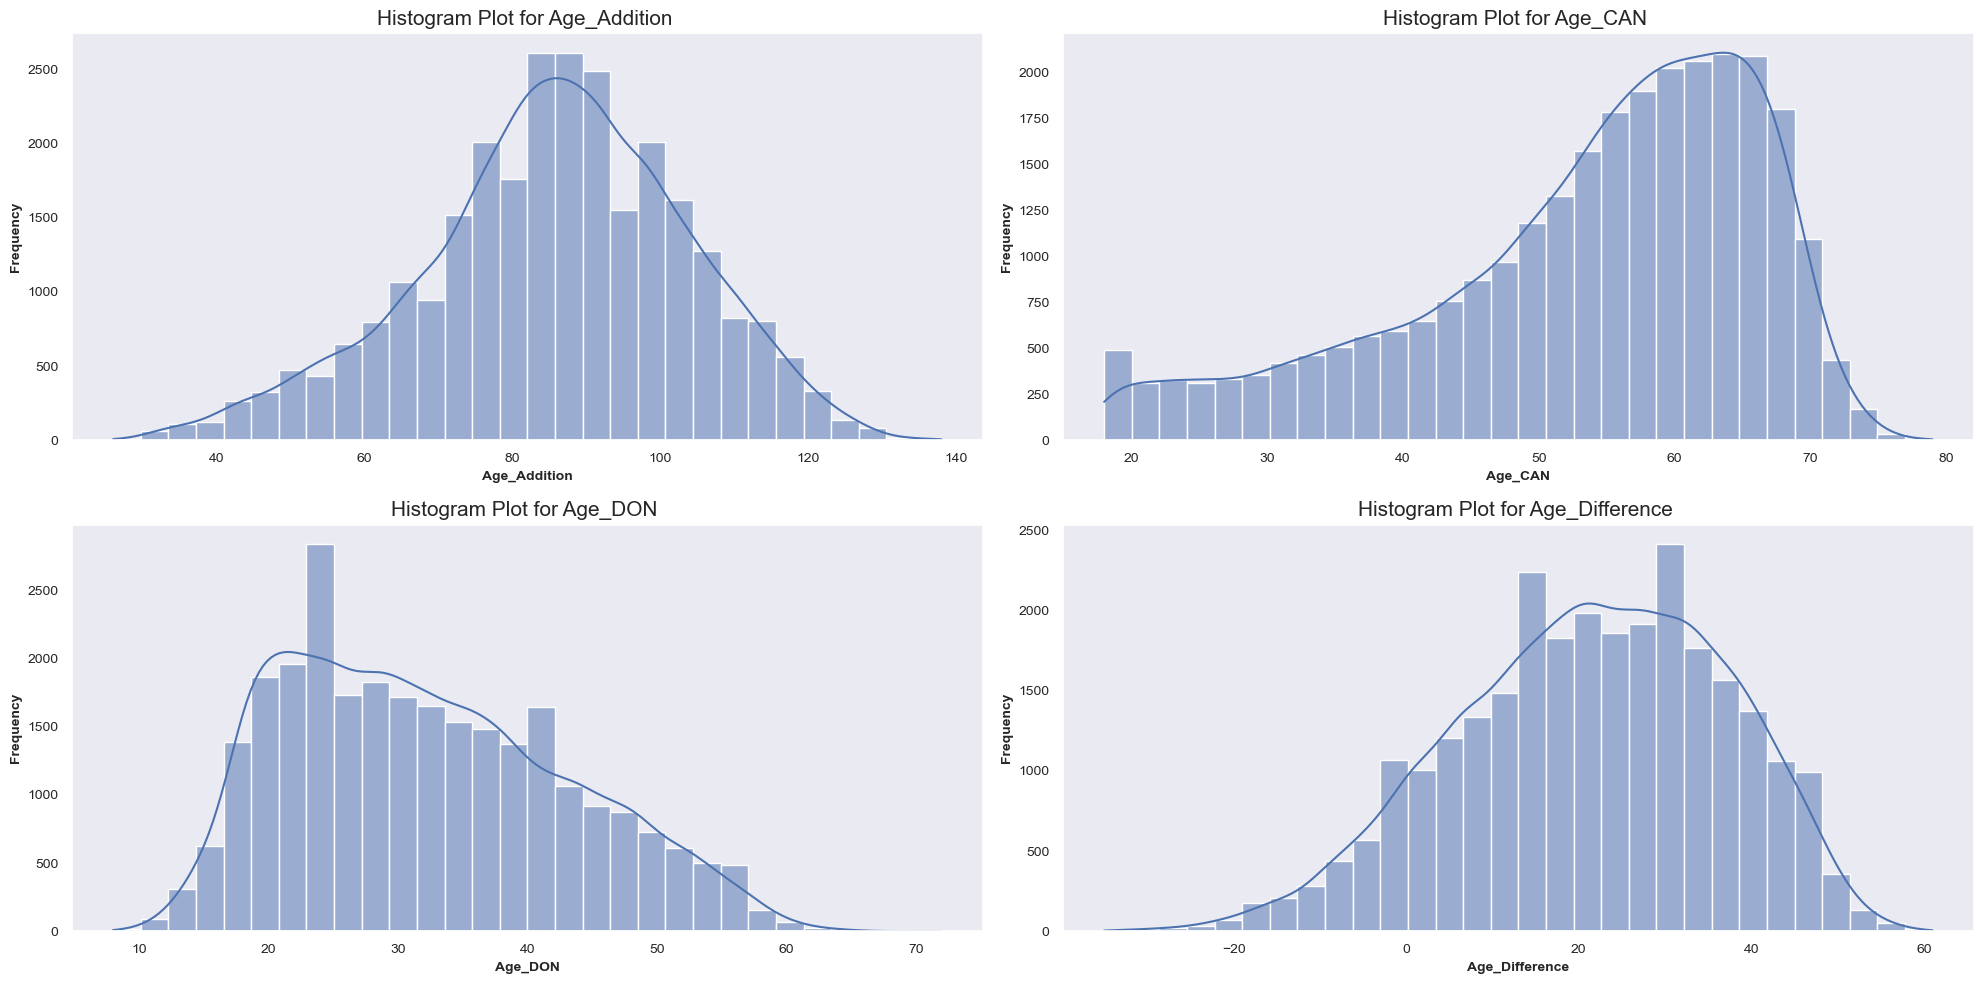

In [15]:
uv.histogramPlot(df, features, bins=30)

#### BMI

In [16]:
features = uf.getFeatureList(df, 'BMI_')

                  count       mean        std        min        25%        50%         75%         max
BMI_Addition    27494.0  95.669325  16.257820  49.180627  84.118155  94.587646  105.844687  182.353109
BMI_CAN         27494.0  47.744963   9.070948  21.793003  41.129492  47.414806   54.120541   85.814455
BMI_DON         27494.0  47.924362  10.533202  20.173913  40.581466  46.242231   53.509462  118.750000
BMI_Difference  27494.0  -0.179399  11.051886 -70.717003  -6.437596   0.829487    7.286279   46.438990

:::: NaN Count:
BMI_Addition      0
BMI_CAN           0
BMI_DON           0
BMI_Difference    0


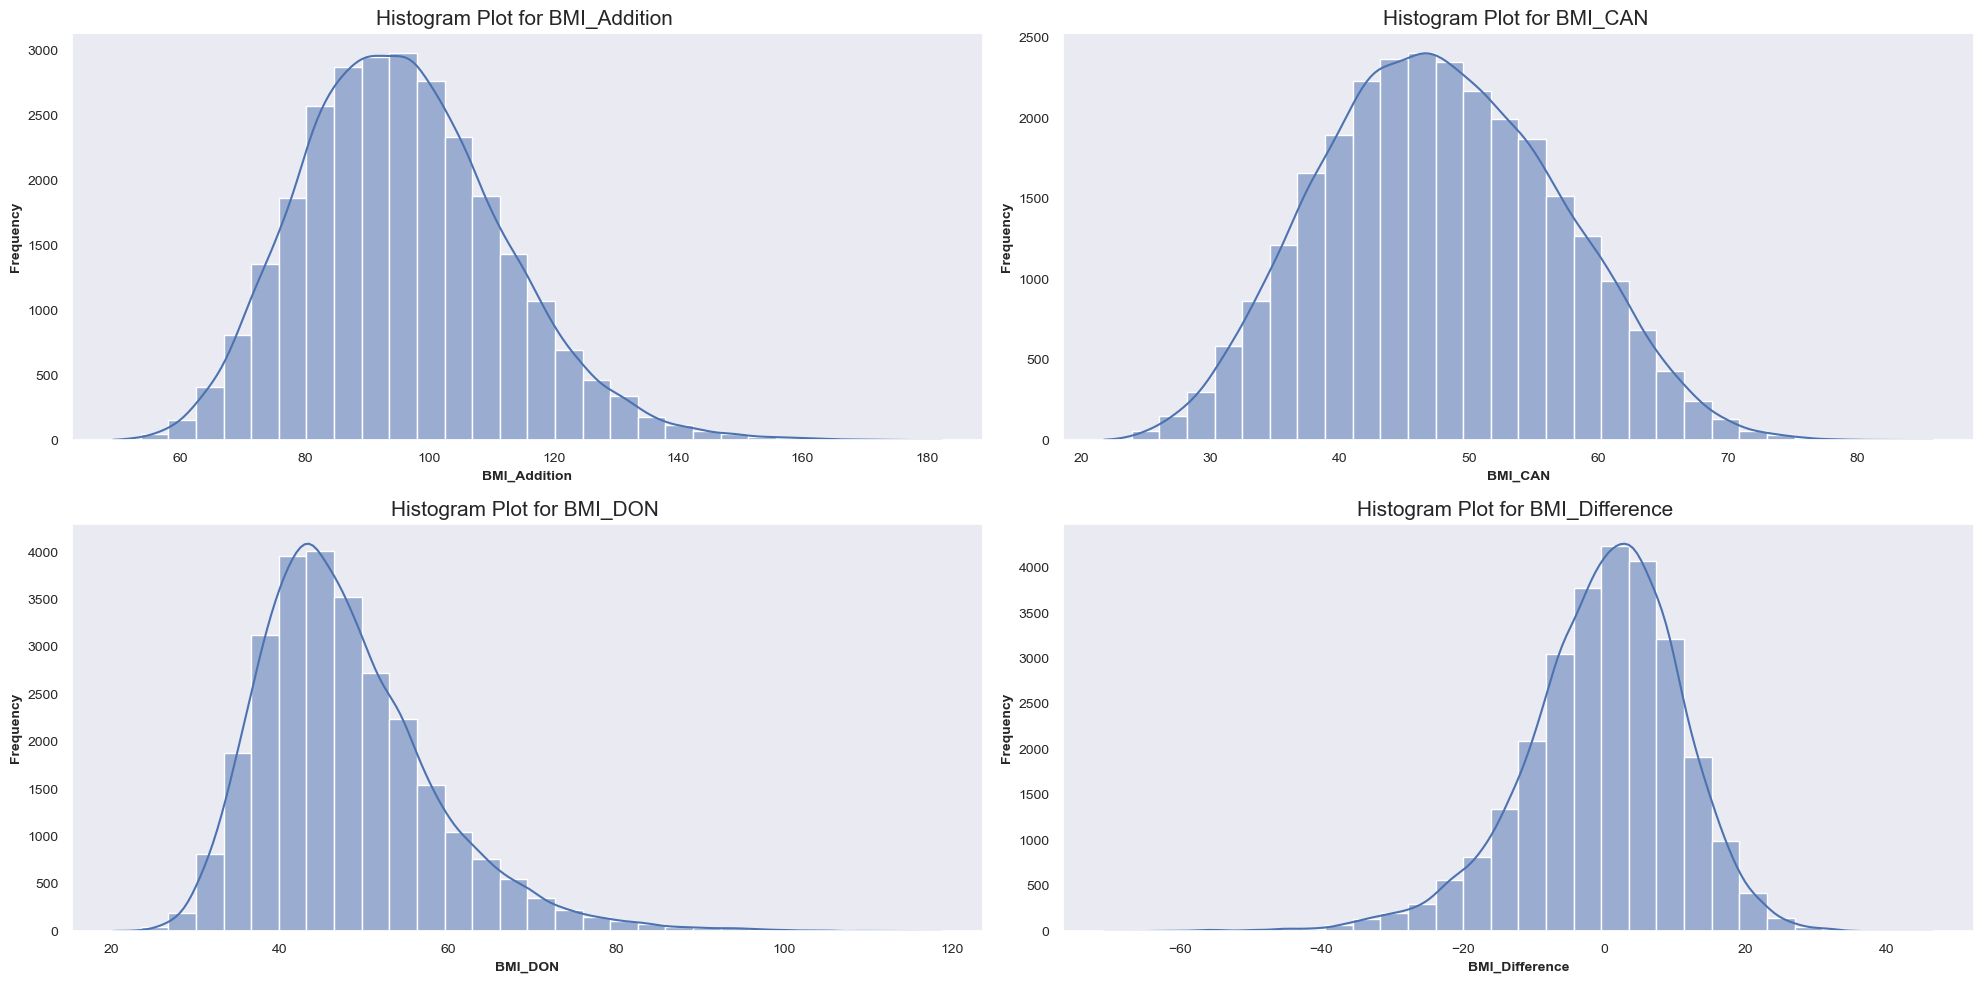

In [17]:
uv.histogramPlot(df, features, bins=30)

#### [BloodPH](https://www.ncbi.nlm.nih.gov/books/NBK507807/)
- The normal blood pH range is indeed between 7.35 and 7.45. This slightly alkaline range is crucial for the proper functioning of enzymes and other biochemical reactions in the body.
    - A blood pH below 7.35 is considered acidic, and it can lead to a condition called acidosis. Acidosis can disrupt cellular functions and impair organ systems, particularly the cardiovascular and respiratory systems.
    - A blood pH above 7.45 is considered alkaline, and it can lead to a condition called alkalosis. Alkalosis can cause symptoms such as muscle twitching, hand tremors, and confusion.

In [18]:
features = uf.getFeatureList(df, 'BloodPH')

               count      mean    std  min   25%   50%   75%   max
BloodPH_DON  27267.0  7.416161  0.074  5.0  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    227


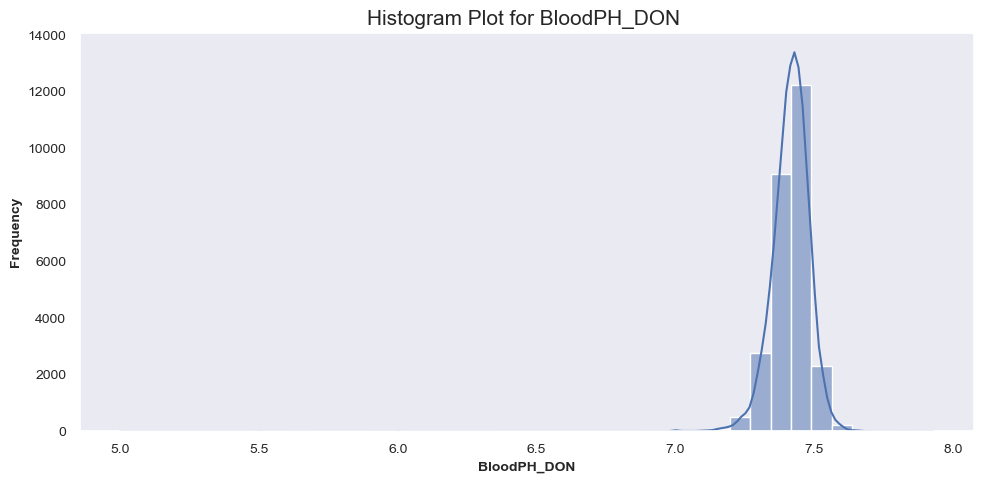

In [19]:
uv.histogramPlot(df, features, bins=40)

#### [BloodUreaNitrogenLevel](https://www.frontiersin.org/journals/cardiovascular-medicine/articles/10.3389/fcvm.2023.1189884/full)

In [20]:
features = uf.getFeatureList(df, 'BloodUreaNitrogenLevel')

                              count       mean        std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  27291.0  24.272559  20.110485  0.5  12.0  18.0  29.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    203


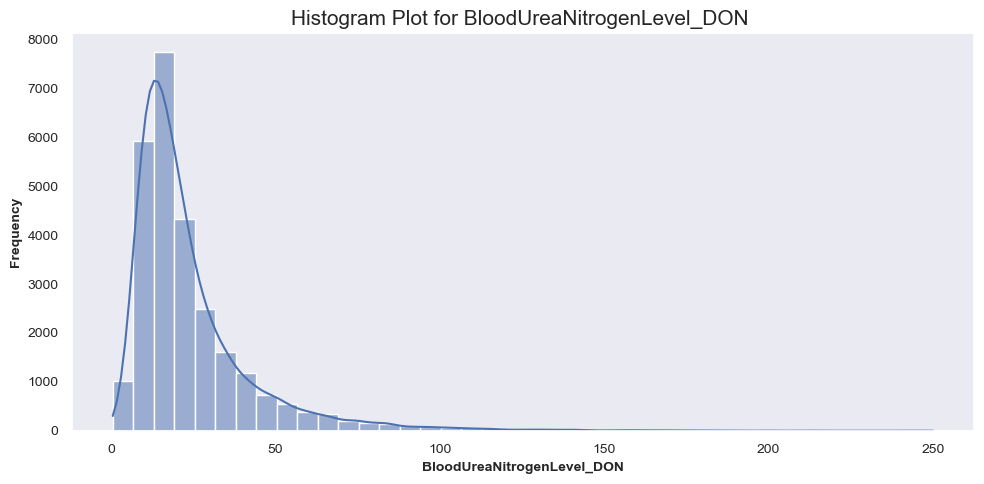

In [21]:
uv.histogramPlot(df, features, bins=40)

#### [Bilirubin](https://www.mountsinai.org/health-library/tests/bilirubin-blood-test)

In [22]:
features = uf.getFeatureList(df, 'Bilirubin')

                                count      mean       std   min  25%  50%  75%   max
TerminalTotalBilirubin_DON    27288.0  1.044261  1.427990   0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  27041.0  0.995037  1.732819   0.1  0.5  0.7  1.1  80.0
TotalBilirubin_Addition       26975.0  2.038524  2.248041   0.3  1.1  1.6  2.2  80.3
TotalBilirubin_Difference     26975.0 -0.049994  2.238960 -44.7 -0.5  0.0  0.4  79.7

:::: NaN Count:
TerminalTotalBilirubin_DON      206
TotalBilirubinTransplant_CAN    453
TotalBilirubin_Addition         519
TotalBilirubin_Difference       519


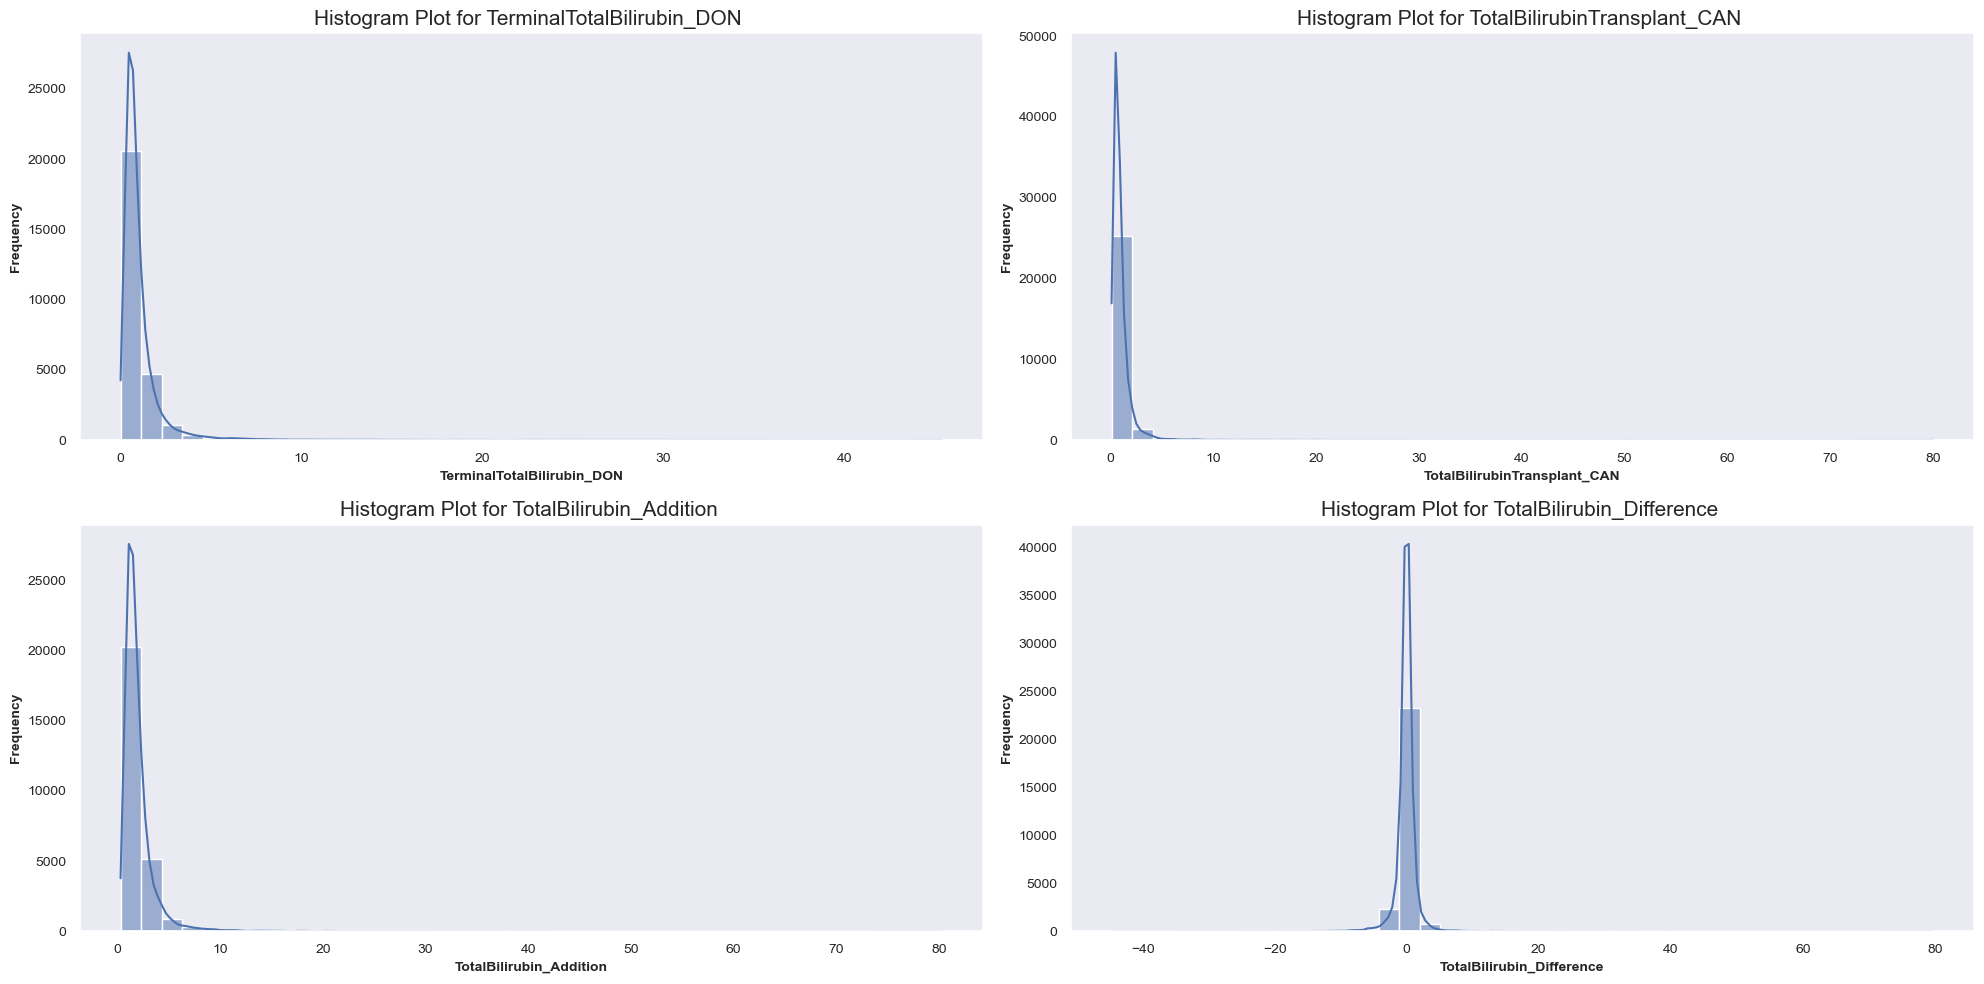

In [23]:
uv.histogramPlot(df, features, bins=40)

#### [Creatinine](https://www.sciencedirect.com/science/article/pii/S0021915014013677?casa_token=ocgbMx1y4ikAAAAA:D0hbOvHvY45rjRH_LgJg62mSRUEu3ky2vZnuyhnyaP6xOphaF8WTWZ2TQ5KqGcNZi0xNrsLvunbZ)

In [24]:
features = uf.getFeatureList(df, 'Creatinine')

                              count      mean       std     min    25%  50%    75%    max
CreatinineRegistration_CAN  27421.0  1.365893  0.963460   0.080  0.940  1.2  1.500  24.00
CreatinineTransplant_CAN    27421.0  1.374737  1.010438   0.060  0.940  1.2  1.500  37.00
Creatinine_Addition_CAN     27421.0  2.740630  1.810664   0.350  1.950  2.4  2.990  49.10
Creatinine_DON              27291.0  1.505226  1.557918   0.040  0.760  1.0  1.500  23.00
Creatinine_Difference_CAN   27421.0 -0.008844  0.787383 -35.890 -0.200  0.0  0.180  20.20
Creatinine_Mean_CAN         27421.0  1.370315  0.905332   0.175  0.975  1.2  1.495  24.55

:::: NaN Count:
CreatinineRegistration_CAN     73
CreatinineTransplant_CAN       73
Creatinine_Addition_CAN        73
Creatinine_DON                203
Creatinine_Difference_CAN      73
Creatinine_Mean_CAN            73


In [25]:
df[features].corr()

,CreatinineRegistration_CAN,CreatinineTransplant_CAN,Creatinine_Addition_CAN,Creatinine_DON,Creatinine_Difference_CAN,Creatinine_Mean_CAN
CreatinineRegistration_CAN,1.000000,0.682714,0.913090,-0.037383,0.347505,0.913090
CreatinineTransplant_CAN,0.682714,1.000000,0.921322,-0.023783,-0.447901,0.921322
Creatinine_Addition_CAN,0.913090,0.921322,1.000000,-0.033185,-0.065042,1.000000
Creatinine_DON,-0.037383,-0.023783,-0.033185,1.000000,-0.015152,-0.033185
Creatinine_Difference_CAN,0.347505,-0.447901,-0.065042,-0.015152,1.000000,-0.065042
Creatinine_Mean_CAN,0.913090,0.921322,1.000000,-0.033185,-0.065042,1.000000


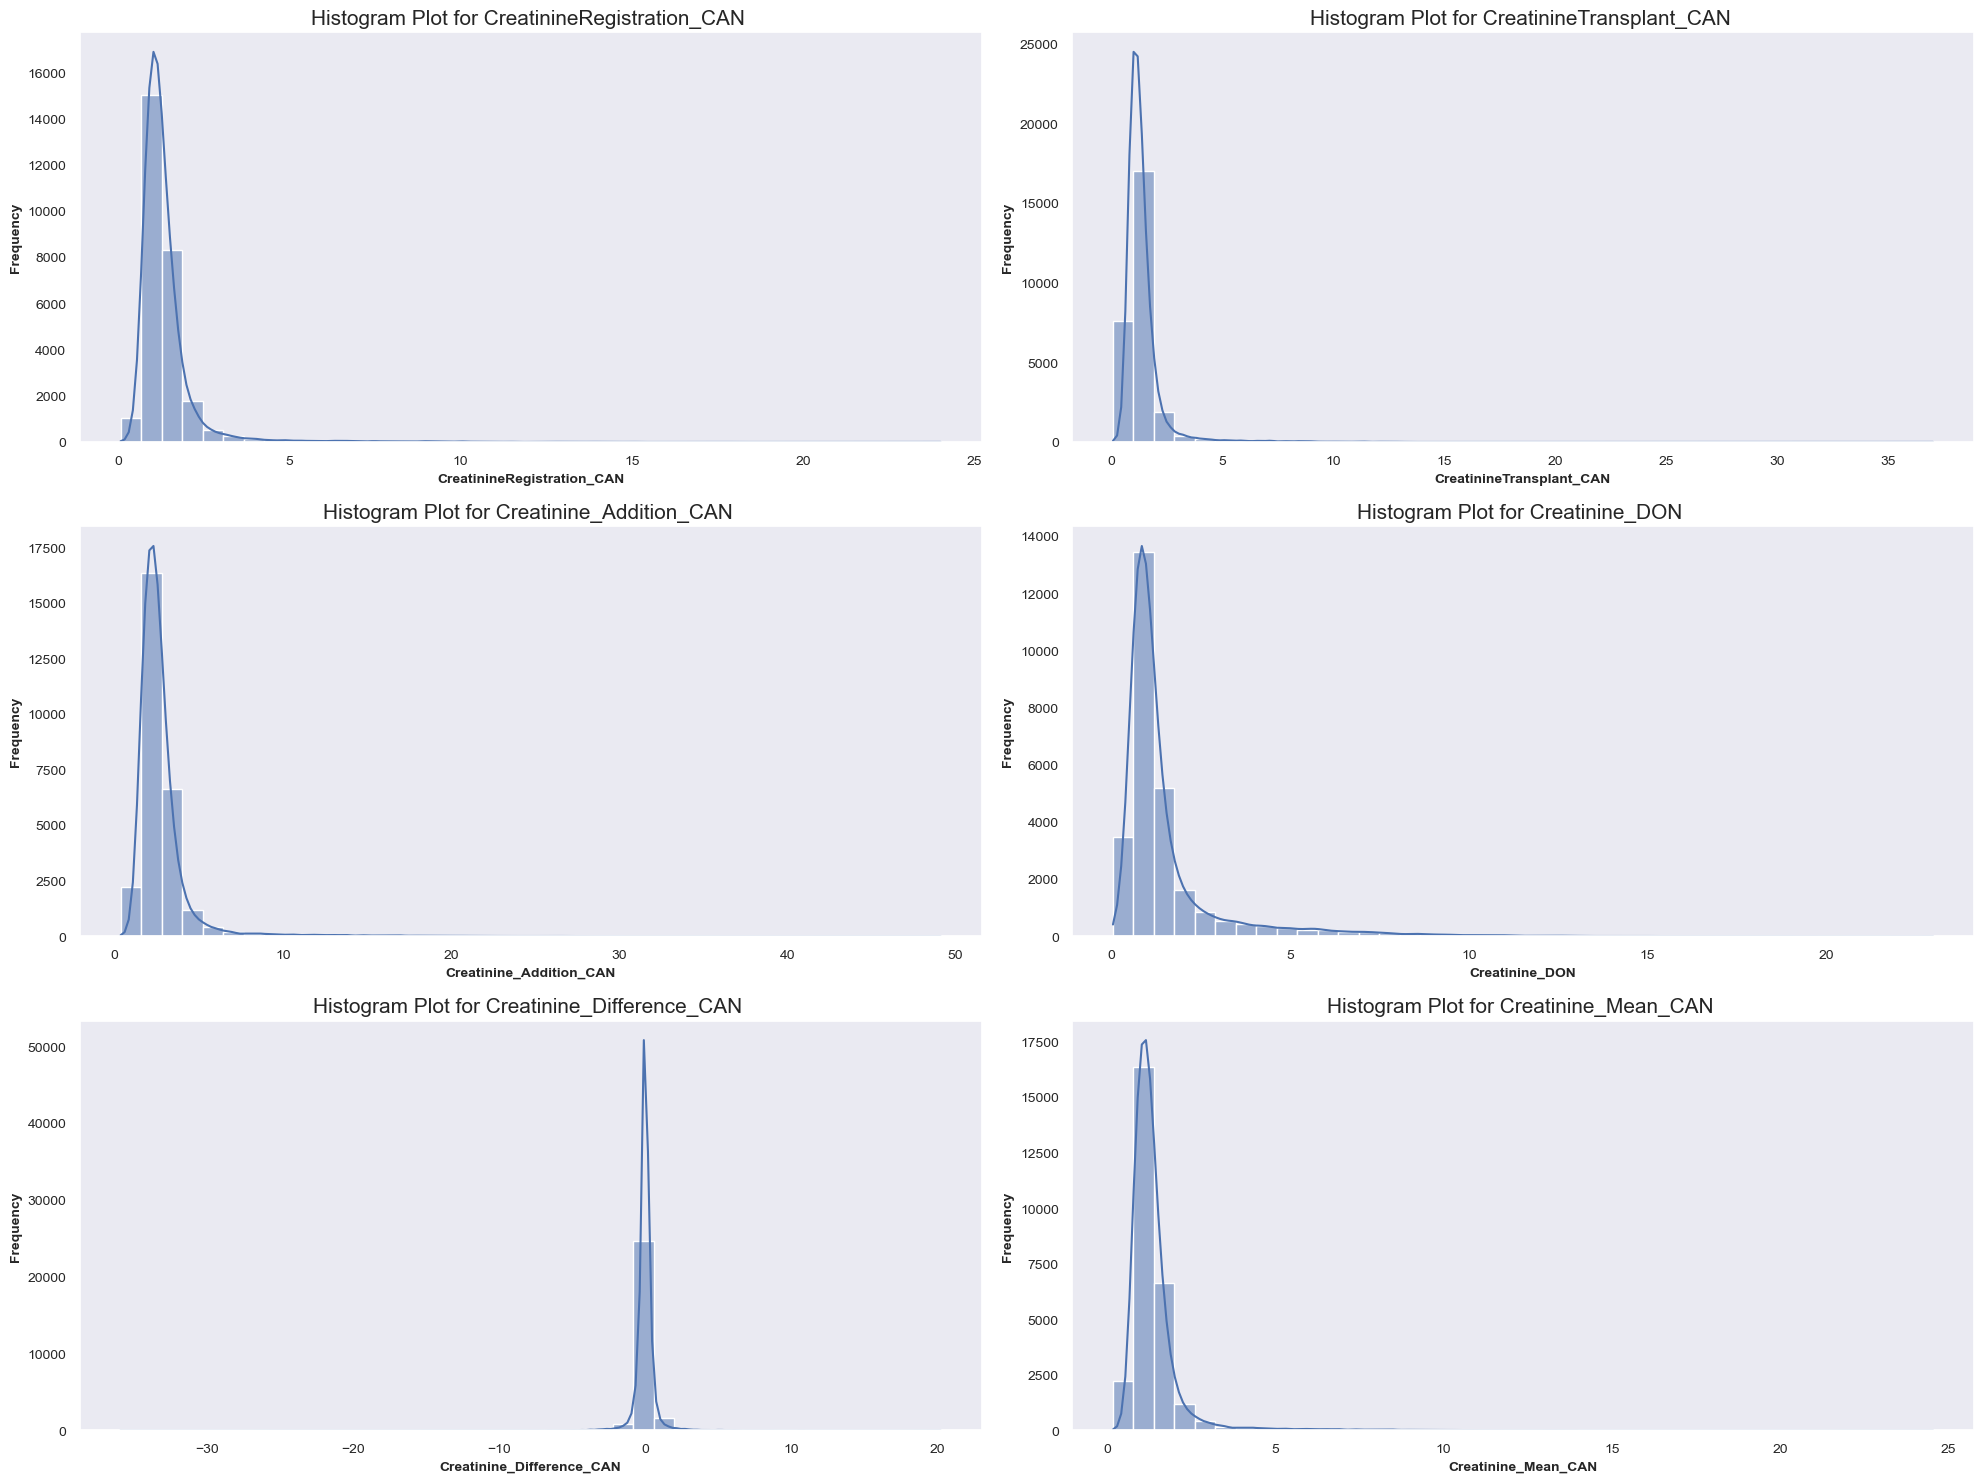

In [26]:
uv.histogramPlot(df, features, bins=40)

#### DistanceFromDonorHospitaltoTXCenter

In [27]:
features = uf.getFeatureList(df, 'DistanceFromDonorHospitaltoTXCenter')

                                       count        mean         std  min   25%    50%    75%     max
DistanceFromDonorHospitaltoTXCenter  27494.0  201.527351  222.020998  0.0  21.0  128.0  322.0  2215.0

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter    0


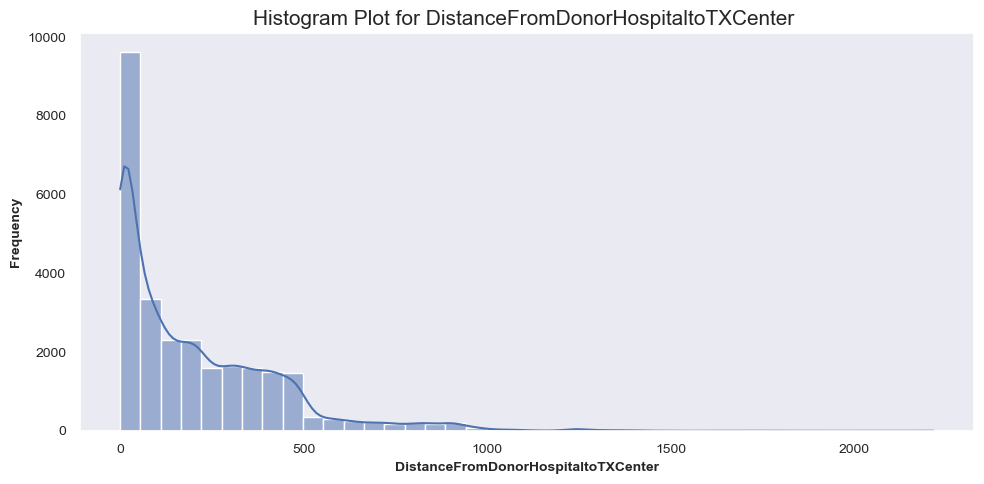

In [28]:
uv.histogramPlot(df, features, bins=40)

#### HeightCm

In [29]:
features = uf.getFeatureList(df, 'HeightCm')

                       count        mean        std    min    25%    50%    75%    max
HeightCm_Addition    27494.0  347.550520  17.053868  239.0  335.3  348.3  360.6  404.1
HeightCm_CAN         27494.0  173.647378  10.039060  124.0  167.6  175.0  180.3  213.4
HeightCm_DON         27494.0  173.903143   9.578505  115.0  167.6  175.0  180.3  213.0
HeightCm_Difference  27494.0   -0.255765   9.707038  -50.8   -6.9    0.0    5.8   43.2

:::: NaN Count:
HeightCm_Addition      0
HeightCm_CAN           0
HeightCm_DON           0
HeightCm_Difference    0


In [30]:
df[features].corr()

,HeightCm_Addition,HeightCm_CAN,HeightCm_DON,HeightCm_Difference
HeightCm_Addition,1.000000,0.875762,0.862560,0.054578
HeightCm_CAN,0.875762,1.000000,0.511152,0.529821
HeightCm_DON,0.862560,0.511152,1.000000,-0.458123
HeightCm_Difference,0.054578,0.529821,-0.458123,1.000000


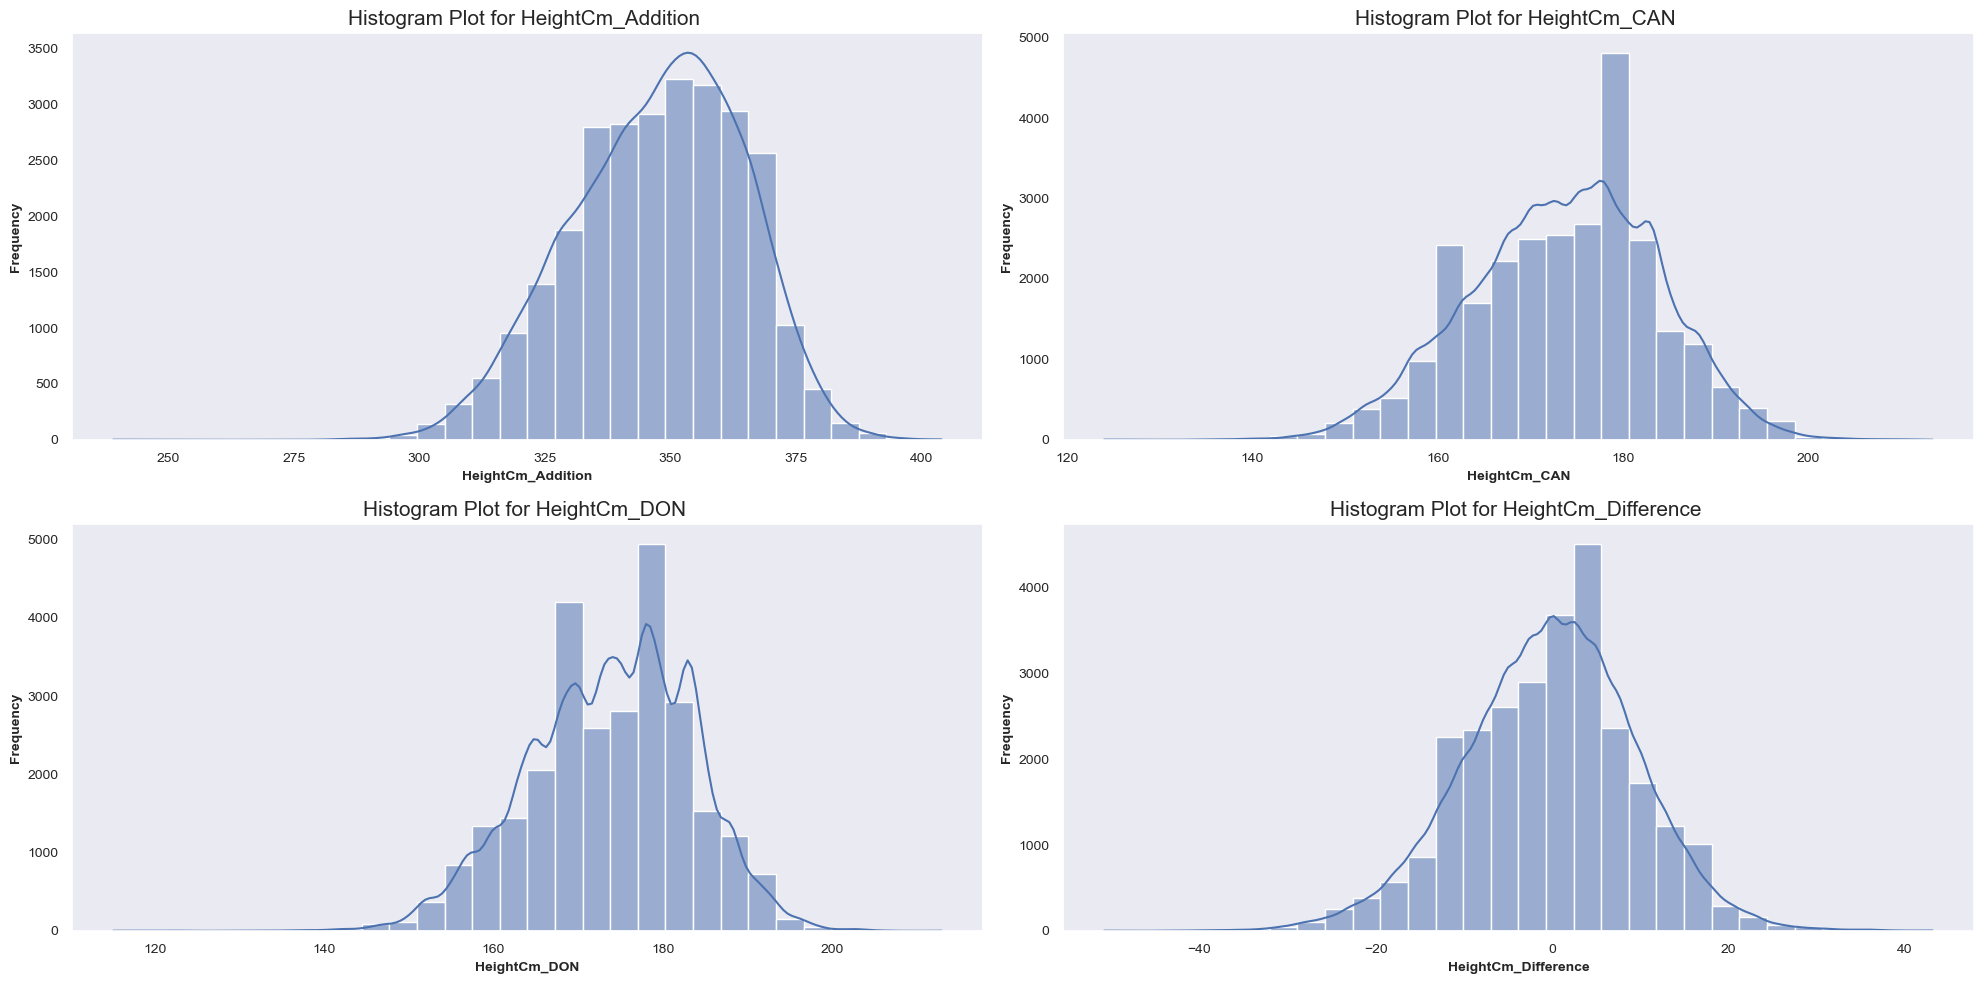

In [31]:
uv.histogramPlot(df, features, bins=30)

#### Hematocrit
- A hematocrit test measures the percentage of red blood cells in your blood. Red blood cells are crucial because they carry oxygen throughout your body.
    - Normal Hematocrit Ranges
        - Men: 38.3% to 48.6%
        - Women: 35.5% to 44.9%  

In [32]:
features = uf.getFeatureList(df, 'Hematocrit')

                  count       mean     std  min   25%   50%   75%   max
Hematocrit_DON  27291.0  28.397493  5.0099  2.3  25.0  27.9  31.3  75.0

:::: NaN Count:
Hematocrit_DON    203


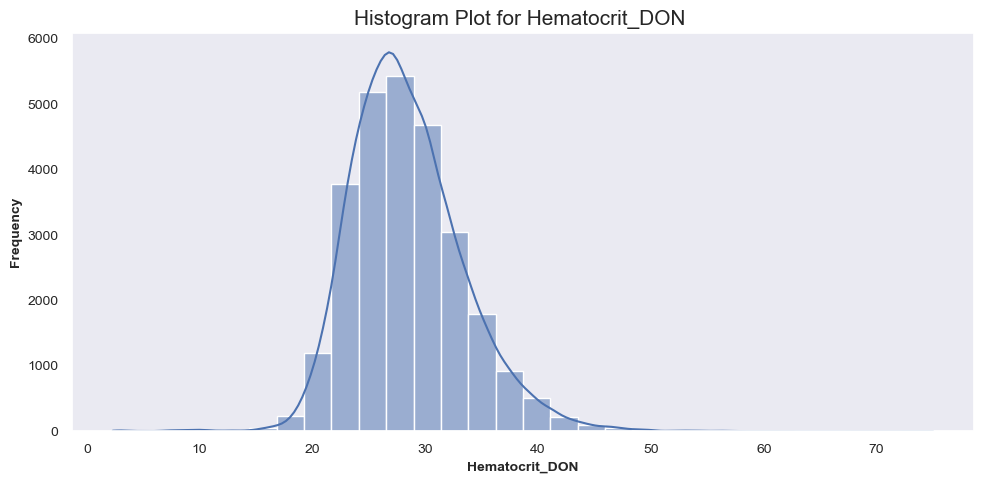

In [33]:
uv.histogramPlot(df, features, bins=30)

#### Hemodynamics

In [34]:
features = uf.getFeatureList(df, 'Hemodynamics')

                                       count           mean           std           min            25%            50%           75%           max
HemodynamicsRegistration_CO_CAN      26871.0       4.277981  1.359766e+00  3.900000e-01       3.330000       4.120000  5.010000e+00  1.500000e+01
HemodynamicsRegistration_PA_DIA_CAN  27018.0      20.443601  8.686121e+00  0.000000e+00      14.000000      20.000000  2.600000e+01  9.100000e+01
HemodynamicsRegistration_PA_MN_CAN   26989.0      28.504873  1.021289e+01  0.000000e+00      21.000000      28.000000  3.600000e+01  9.600000e+01
HemodynamicsRegistration_PCW_CAN     26482.0      19.101427  8.833046e+00  0.000000e+00      12.000000      19.000000  2.500000e+01  5.000000e+01
HemodynamicsRegistration_SYS_CAN     27026.0      41.843262  1.424661e+01  0.000000e+00      31.000000      41.000000  5.100000e+01  1.300000e+02
HemodynamicsTransplant_CO_CAN        26871.0       4.521705  1.459440e+00  2.000000e-01       3.500000       4.370000  5.315

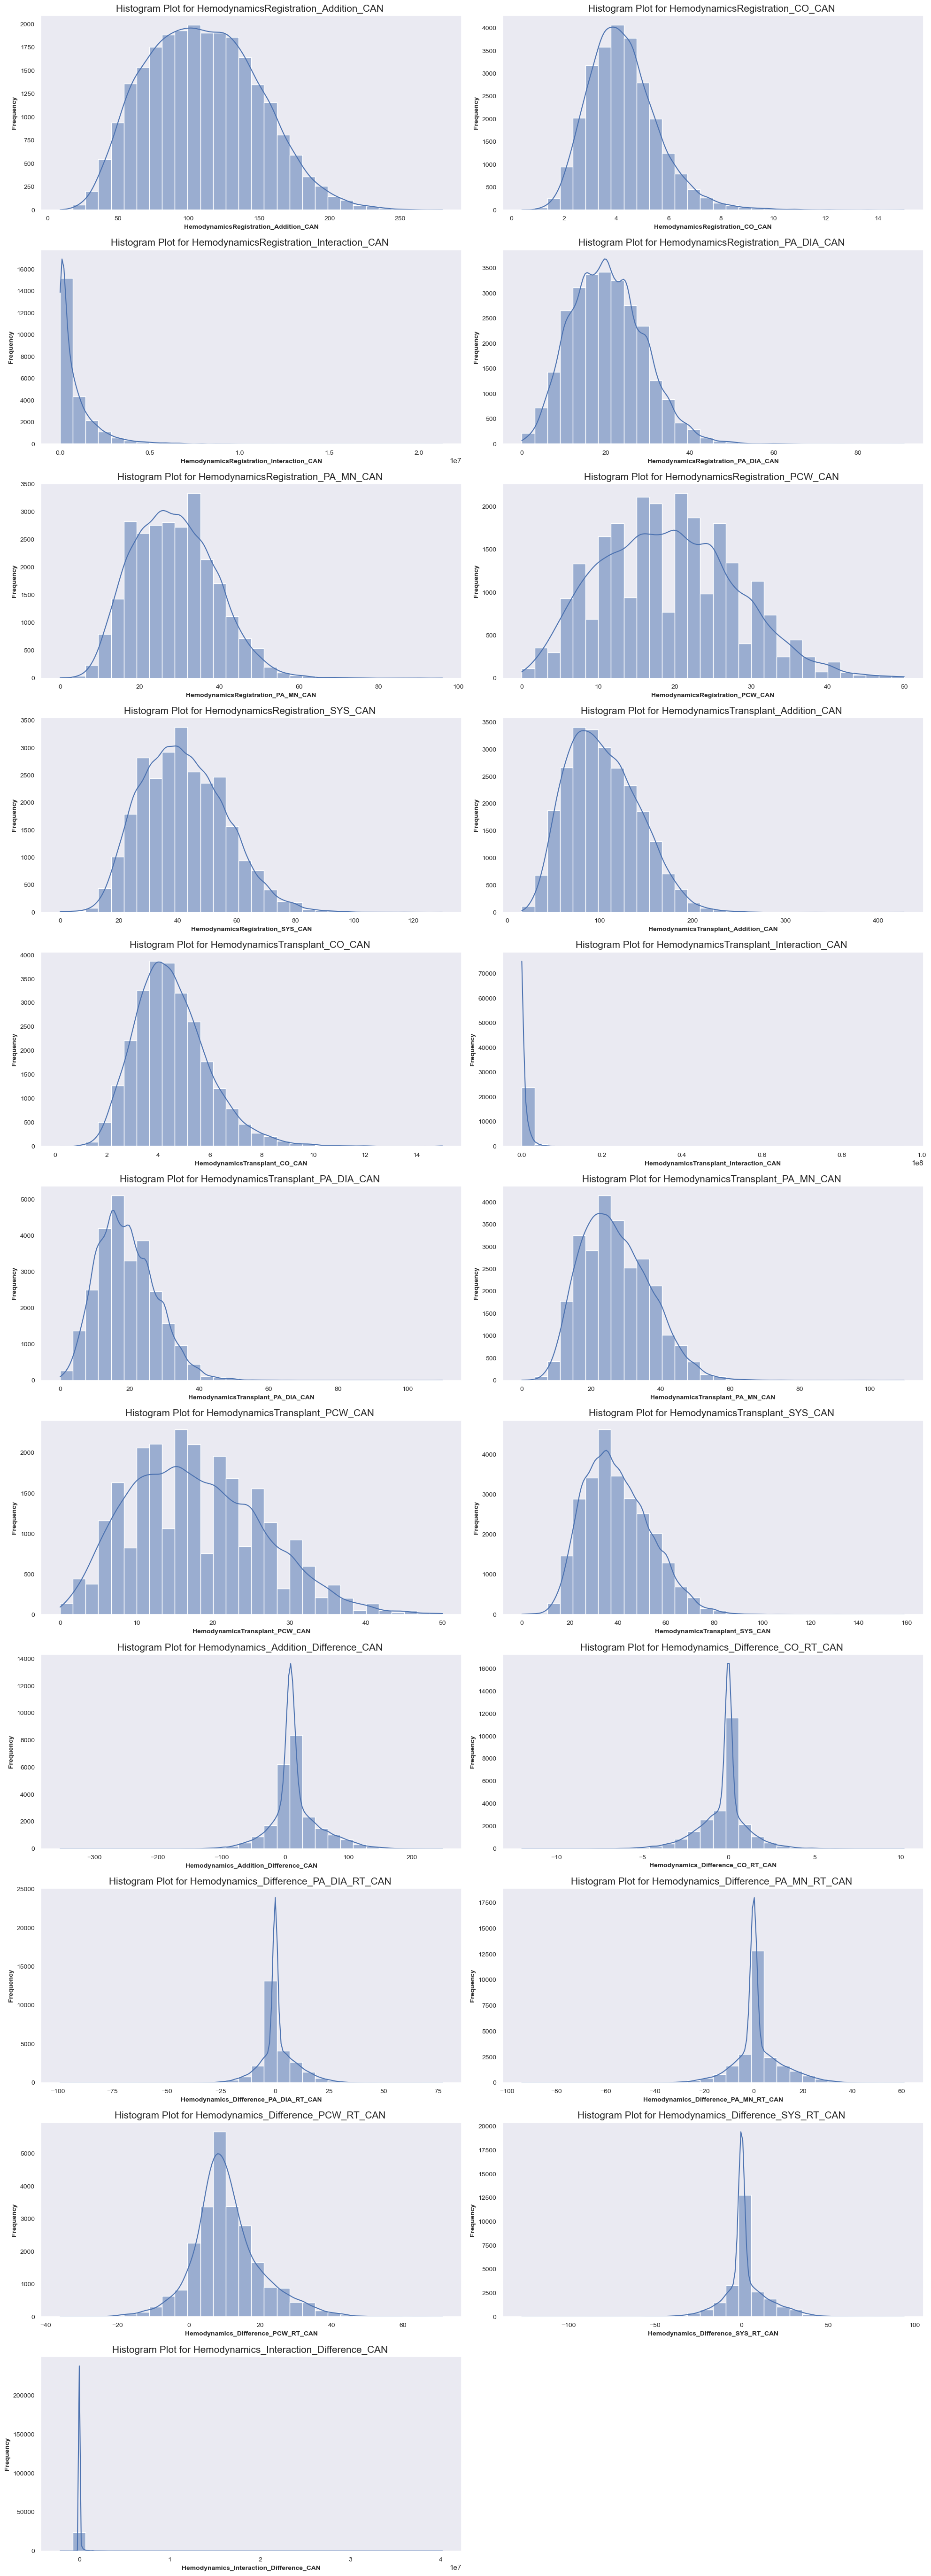

In [38]:
uv.histogramPlot(df, features, bins=30)

In [11]:
print(sorted(numericCols))

['Age_Addition', 'Age_CAN', 'Age_DON', 'Age_Difference', 'BMI_Addition', 'BMI_CAN', 'BMI_DON', 'BMI_Difference', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_Addition_CAN', 'Creatinine_DON', 'Creatinine_Difference_CAN', 'Creatinine_Mean_CAN', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_Addition', 'HeightCm_CAN', 'HeightCm_DON', 'HeightCm_Difference', 'Hematocrit_DON', 'HemodynamicsRegistration_Addition_CAN', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_Interaction_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_Addition_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_Interaction_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'Hemodynamics_Addition_Differe

#### [Level_SGOT](https://www.mdpi.com/2073-4409/9/3/567)
- SGOT (AST) and ALT are enzymes that are commonly measured to assess liver health:
    - SGOT (AST): Also known as aspartate aminotransferase (AST), this enzyme is found in various tissues, including the liver, heart, muscles, and kidneys. It plays a role in amino acid metabolism. Elevated levels of AST in the blood can indicate liver damage, heart problems, or muscle injury.
        - Conservative normal range of 8 to 45 units/L for healthy individuals. 
    - SGOT (ALT): Also known as alanine aminotransferase (ALT), this enzyme is primarily found in the liver. It helps convert proteins into energy for liver cells. High levels of ALT are more specific to liver damage compared to AST.
        - The typical normal range for ALT is approximately 7 to 56 units per liter (U/L) of serum. However, ranges may vary slightly between laboratories. 

In [32]:
features = uf.getFeatureList(df, 'SGOT')

                               count          mean           std     min    25%     50%     75%         max
Level_SGOT_ALT_DON           27287.0    114.875032  4.088725e+02     3.0   23.0    41.0    83.0     44117.0
Level_SGOT_AST_DON           27287.0    102.015934  3.025393e+02     0.3   26.0    44.0    87.0     10254.0
Level_SGOT_Addition_DON      27287.0    216.890966  6.295176e+02     9.0   55.0    92.0   177.0     44267.0
Level_SGOT_Difference_DON    27287.0     12.859098  3.480244e+02 -7648.0  -22.0    -2.0    18.0     43967.0
Level_SGOT_Interraction_DON  27287.0  80509.423645  1.185698e+06     5.2  682.0  1856.0  6577.5  89360739.0

:::: NaN Count:
Level_SGOT_ALT_DON             207
Level_SGOT_AST_DON             207
Level_SGOT_Addition_DON        207
Level_SGOT_Difference_DON      207
Level_SGOT_Interraction_DON    207


In [33]:
df[features].corr()

,Level_SGOT_ALT_DON,Level_SGOT_AST_DON,Level_SGOT_Addition_DON,Level_SGOT_Difference_DON,Level_SGOT_Interraction_DON
Level_SGOT_ALT_DON,1.000000,0.556127,0.916770,0.691395,0.537577
Level_SGOT_AST_DON,0.556127,1.000000,0.841794,-0.215946,0.815187
Level_SGOT_Addition_DON,0.916770,0.841794,1.000000,0.345281,0.740927
Level_SGOT_Difference_DON,0.691395,-0.215946,0.345281,1.000000,-0.077079
Level_SGOT_Interraction_DON,0.537577,0.815187,0.740927,-0.077079,1.000000


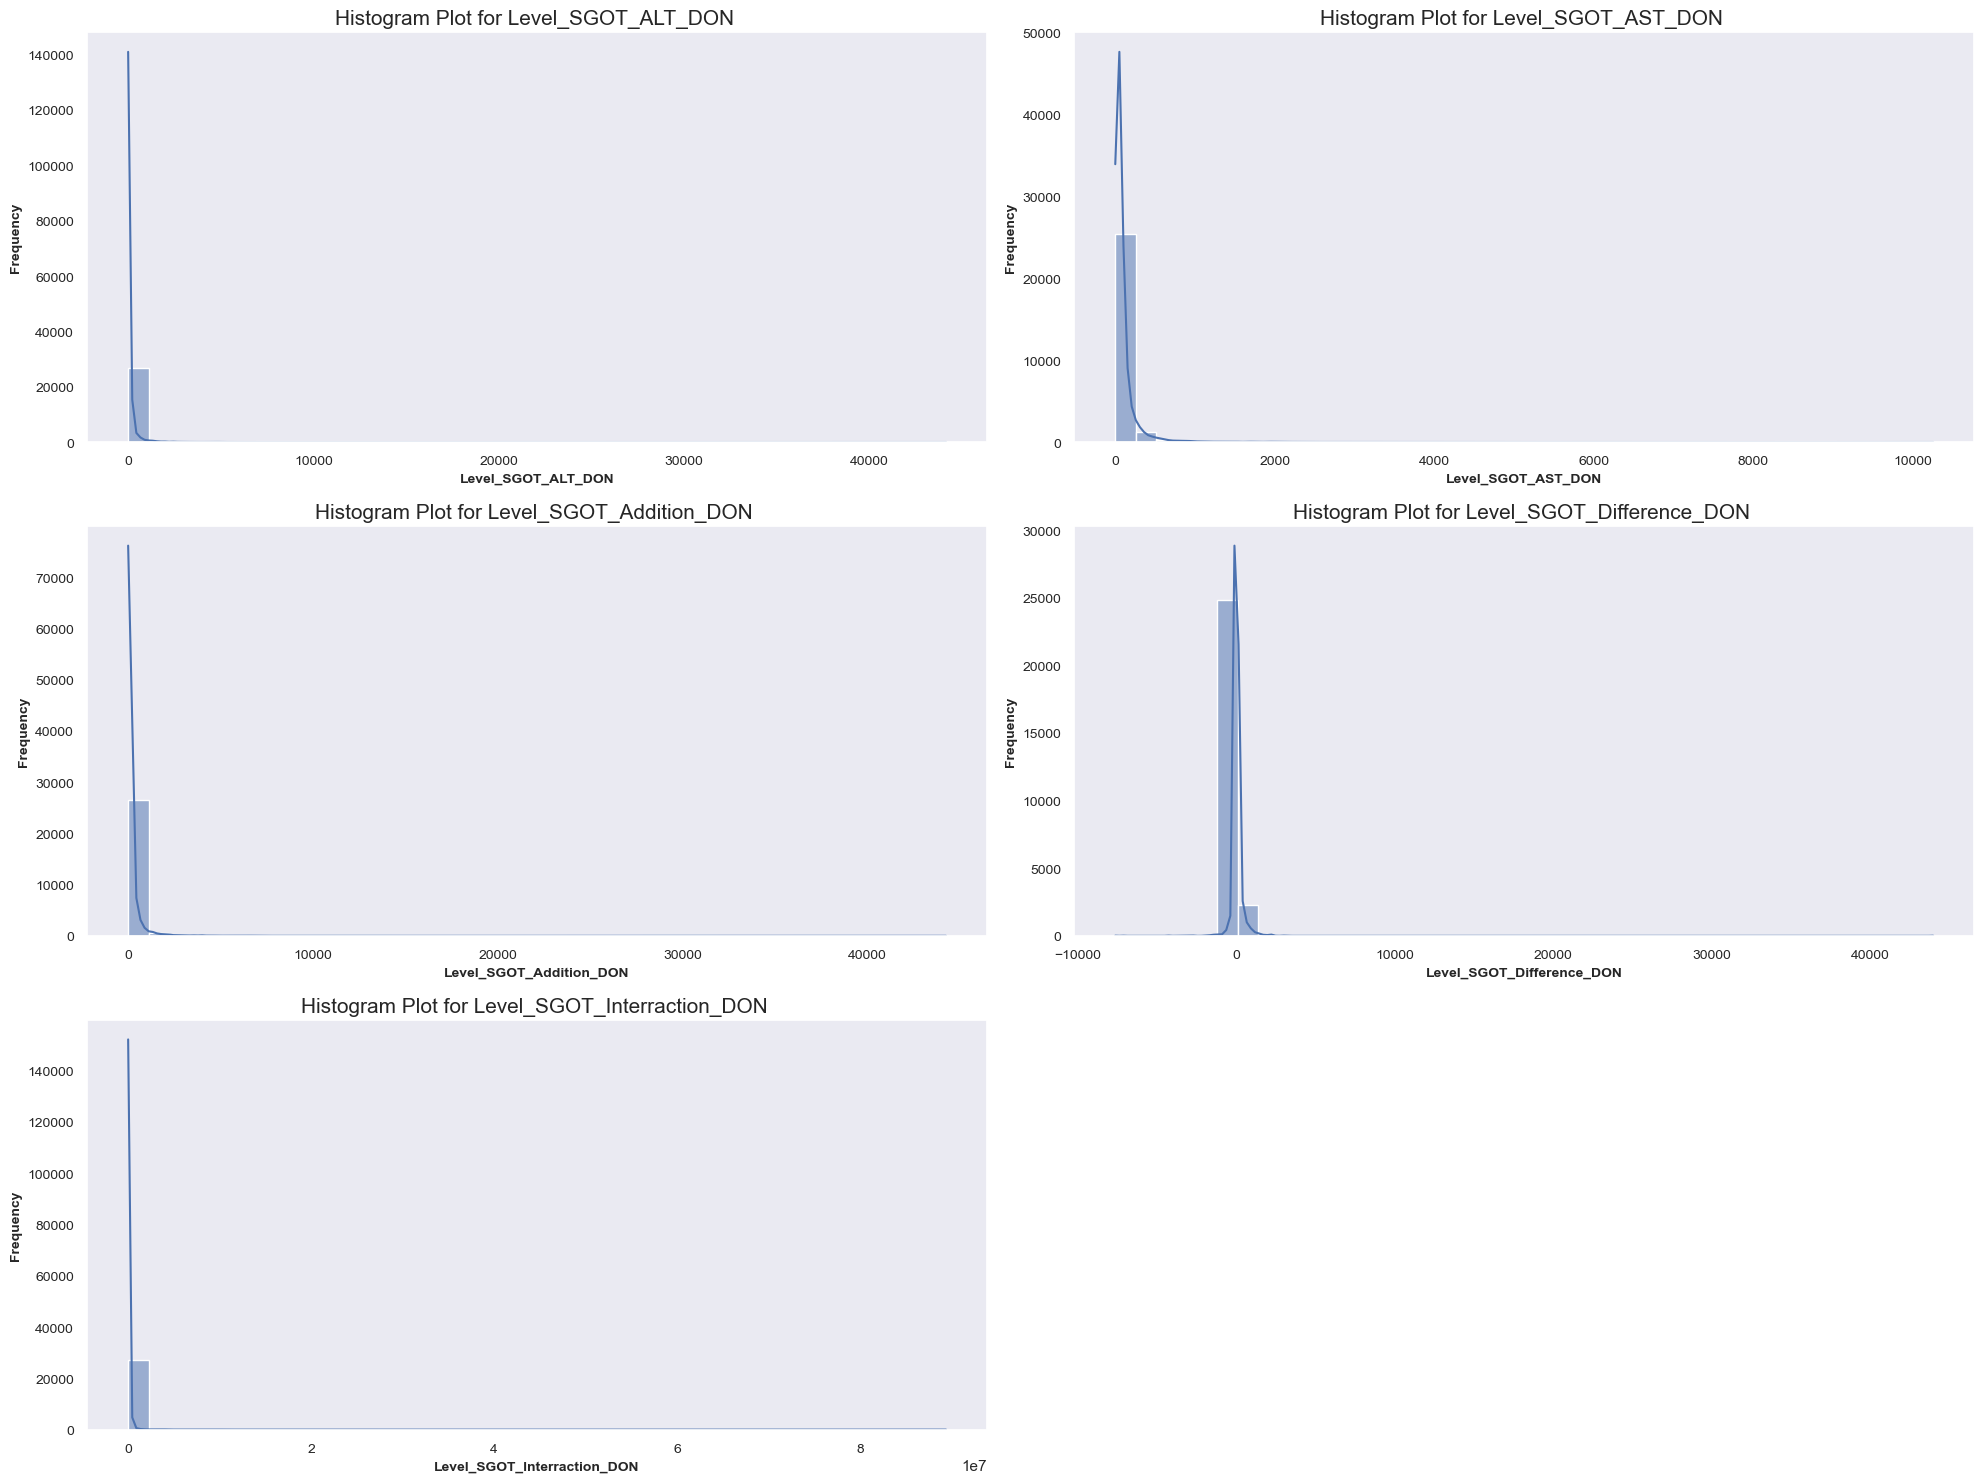

In [34]:
uv.histogramPlot(df, features, bins=40)

### Split Dataset

In [26]:
# import library
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import QuantileTransformer

# split the data into training and testing sets
train_data, test_data = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

In [27]:
train_data.shape, test_data.shape

((21655, 212), (5414, 212))

#### Histogram Before Transformation

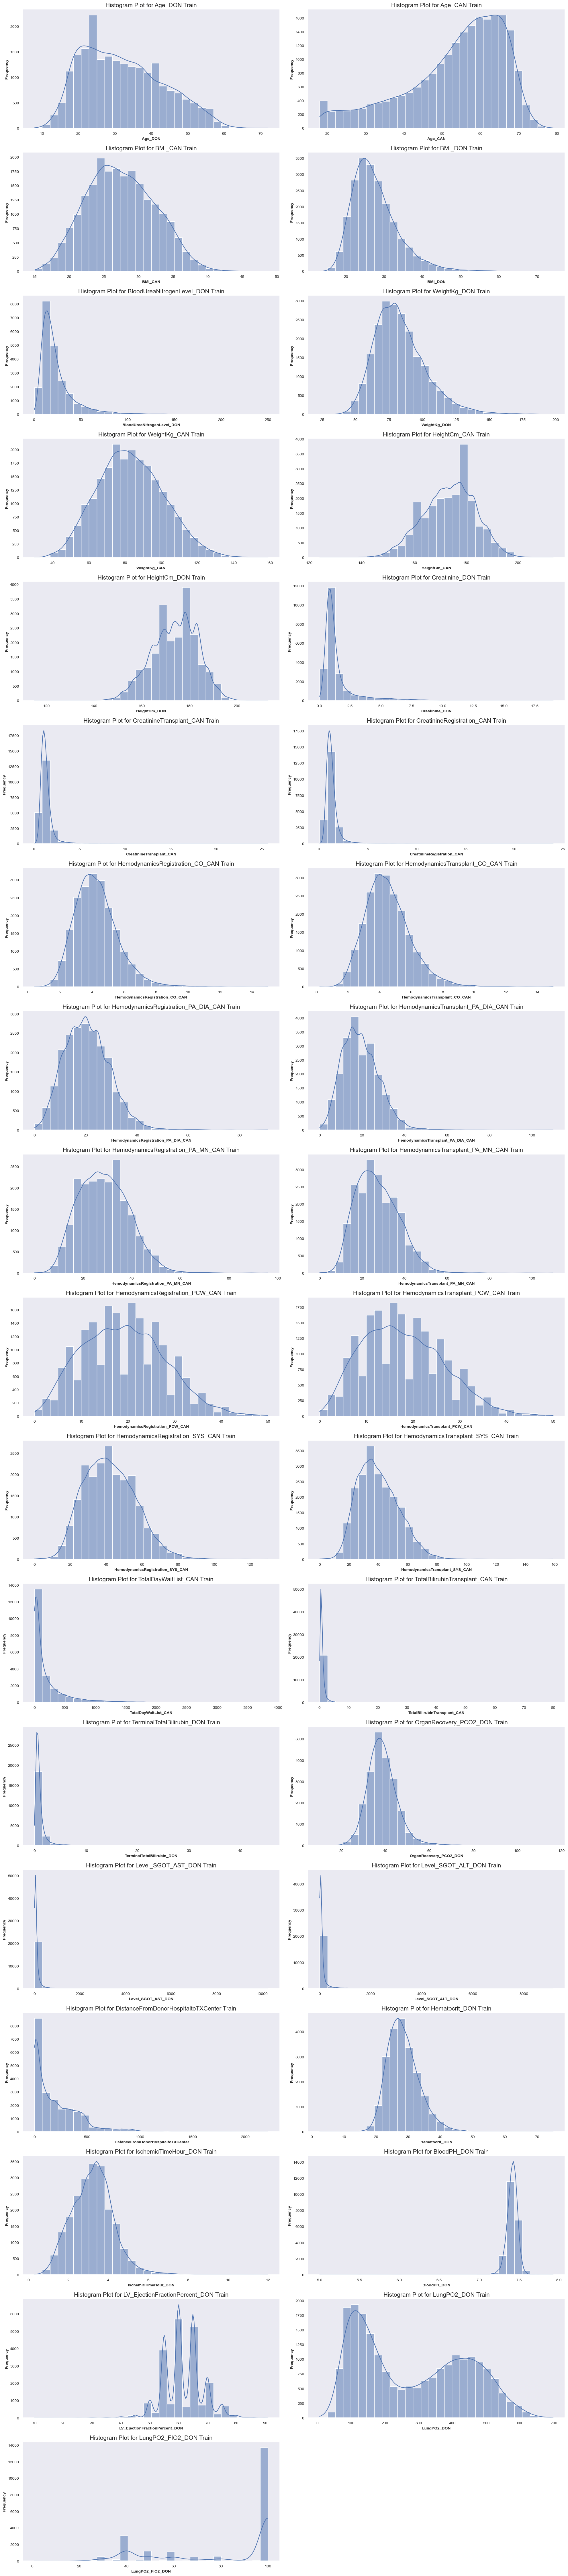

In [28]:
uv.histogramPlot(train_data, numericCols, bins=30, txt='Train')

#### [Quantile Transformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html)
- The `QuantileTransformer` is a non-linear transformation that maps data to a uniform or normal distribution based on quantiles. It helps make data more Gaussian-like and is particularly useful when dealing with skewed or heavy-tailed distributions. Feature independence in the context of the `QuantileTransformer` means that each feature (or column) in your dataset is transformed independently of the others.
    - Feature Independence: The `QuantileTransformer` operates independently on each feature, so it doesn't require the features to be on the same scale.
    - Outliers: The `QuantileTransformer` is robust to outliers, as it spreads out the most frequent values and reduces the impact of marginal outliers.
    - Non-linear Transformation: Since the transformation is non-linear, it may distort linear relationships between variables. If preserving linear relationships is important for your analysis, you might want to consider other scaling methods.

In [31]:
# initialize transformer
transformer = QuantileTransformer(output_distribution='normal', n_quantiles=2000, random_state=RANDOM_STATE)

# fit the transformer on the training data
transformer.fit(train_data[numericCols])

QuantileTransformer(n_quantiles=2000, output_distribution='normal',
                    random_state=1776)

In [32]:
# transform both the training and testing data
train_data_transformed = pd.DataFrame(transformer.transform(train_data[numericCols]),columns=numericCols)
test_data_transformed = pd.DataFrame(transformer.transform(test_data[numericCols]),columns=numericCols)

- For the normal distribution (output_distribution='normal'):
    - The transformed values approximate a standard normal distribution.
    - Extreme values are mapped to the tails of the normal distribution.
    - The highest value is typically mapped close to 3 (3 standard deviations above the mean).

In [38]:
train_data_transformed.describe().T

,count,mean,std,min,25%,50%,75%,max
Age_DON,21655.0,-0.001761,0.999583,-5.199338,-0.691511,0.008778,0.677247,5.199338
Age_CAN,21655.0,-0.016138,1.075381,-5.199338,-0.684362,-0.025709,0.646804,5.199338
BMI_CAN,21643.0,0.003493,0.999326,-5.199338,-0.670952,0.018183,0.691511,5.199338
BMI_DON,21649.0,0.001690,0.998931,-5.199338,-0.666609,-0.000599,0.678894,5.199338
BloodUreaNitrogenLevel_DON,21614.0,0.000318,1.003988,-5.199338,-0.727804,-0.025709,0.699496,5.199338
WeightKg_DON,21652.0,0.005182,0.999217,-5.199338,-0.659219,-0.000627,0.674883,5.199338
WeightKg_CAN,21649.0,0.004353,0.997399,-5.199338,-0.661559,0.013167,0.672129,5.199338
HeightCm_CAN,21655.0,0.003546,0.995759,-5.199338,-0.602602,-0.004389,0.627601,5.199338
HeightCm_DON,21655.0,0.006364,0.996675,-5.199338,-0.682778,0.020064,0.663901,5.199338
Creatinine_DON,21614.0,-0.001178,0.994696,-5.199338,-0.680623,-0.008151,0.683569,5.199338


#### Histogram After Transformation

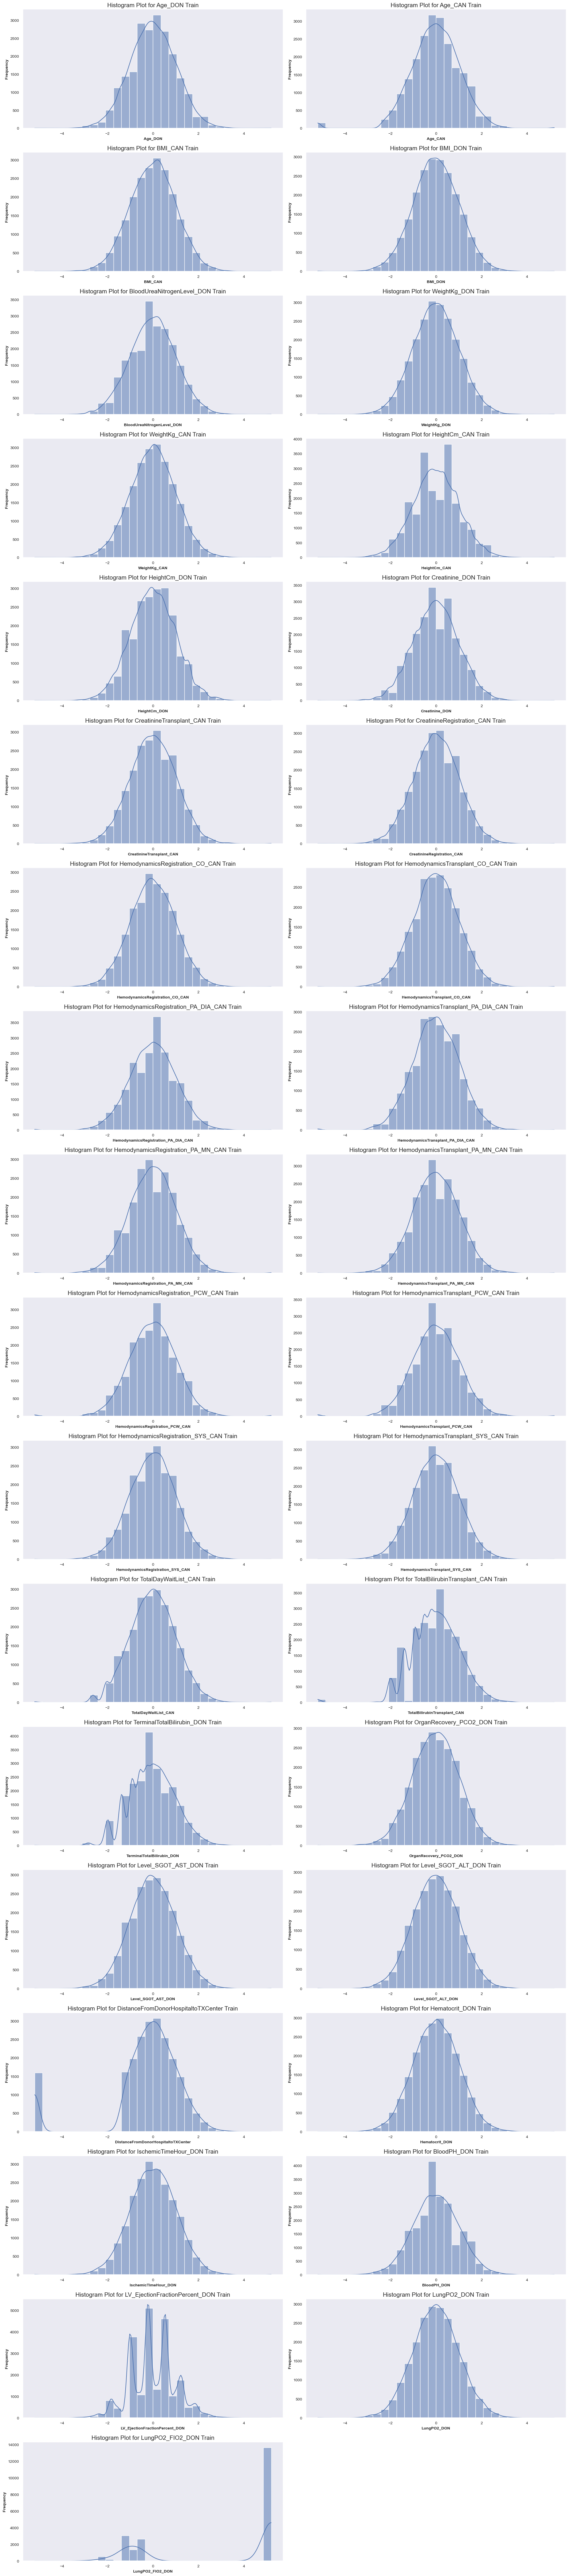

In [34]:
uv.histogramPlot(train_data_transformed, numericCols, bins=30, txt='Train')

##### Lung PO2
- Lung PO2 (Partial Pressure of Oxygen) is a measure of the pressure exerted by oxygen in the lungs. It is an important indicator of how well oxygen is being transferred from the air in the lungs to the blood. The value of PO2 is typically measured in millimeters of mercury (mmHg) and provides insight into the efficiency of the respiratory system. In clinical and transplant contexts, particularly with donors, it helps assess the oxygenation status of the donor’s lungs, which is critical when evaluating organs for transplantation. `LungPO2_DON`: PO2 on 100% oxygen refers to the partial pressure of oxygen in arterial blood when a patient is breathing 100% oxygen.

- The Fraction of Inspired Oxygen (Lung FIO2) refers to the concentration of oxygen in the air that is being inhaled by a patient. It is a critical parameter in managing patients with respiratory distress and is often expressed as a percentage or as a decimal. `LungPO2_FIO2_DON`: Lung pO2 on FiO2 refers to the partial pressure of oxygen in arterial blood (PaO2) in relation to the fraction of inspired oxygen (FiO2).
    - Normal Range for FIO2
        - Room Air: The FIO2 in room air is approximately 21% or 0.21 as a decimal.
    - Supplemental Oxygen:
        - Low-Flow Oxygen Therapy: FIO2 can range from about 24% (0.24) to 40% (0.40), depending on the delivery device (e.g., nasal cannula, simple face mask).
        - High-Flow Oxygen Therapy: FIO2 can be set between 40% (0.40) and 100% (1.0), especially in more controlled environments like intensive care units.<br>

In [ ]:
# all to removeCols
removeCols = ['']

### Wrangle Data

#### Examine NaNs: Full Dataset

In [13]:
# all new features
new = df_new.column.to_list()
# all features
entire = df.columns.to_list()
# remove new from list
result = list(set(entire) - set(new))

# get NaNs
NaNsDF = uf.percentageNull(df[result])

# display NaNs
NaNsDF

,percentage,NaNCount
CPRA_Peak_CAN,23.578116,3702
CPRA_Recent_CAN,23.488950,3688
HemodynamicsRegistration_PCW_CAN,8.744666,1373
HemodynamicsTransplant_PCW_CAN,7.509076,1179
HemodynamicsRegistration_CO_CAN,5.190752,815
HemodynamicsTransplant_CO_CAN,4.643016,729
HemodynamicsTransplant_PA_MN_CAN,3.942424,619
HemodynamicsRegistration_PA_MN_CAN,3.923317,616
HemodynamicsRegistration_PA_DIA_CAN,3.413795,536
HemodynamicsRegistration_SYS_CAN,3.343736,525


#### CPRA

In [15]:
# examine features
features = uf.getFeatureList(df[result], 'CPRA')

                   count       mean        std  min  25%  50%   75%    max
CPRA_Peak_CAN    11999.0  14.944579  26.605557  0.0  0.0  0.0  19.0  100.0
CPRA_Recent_CAN  12013.0  11.254558  23.442261  0.0  0.0  0.0   7.0  100.0

:::: NaN Count:
CPRA_Peak_CAN      3702
CPRA_Recent_CAN    3688


In [16]:
df[features].corr()

,CPRA_Peak_CAN,CPRA_Recent_CAN
CPRA_Peak_CAN,1.000000,0.901139
CPRA_Recent_CAN,0.901139,1.000000


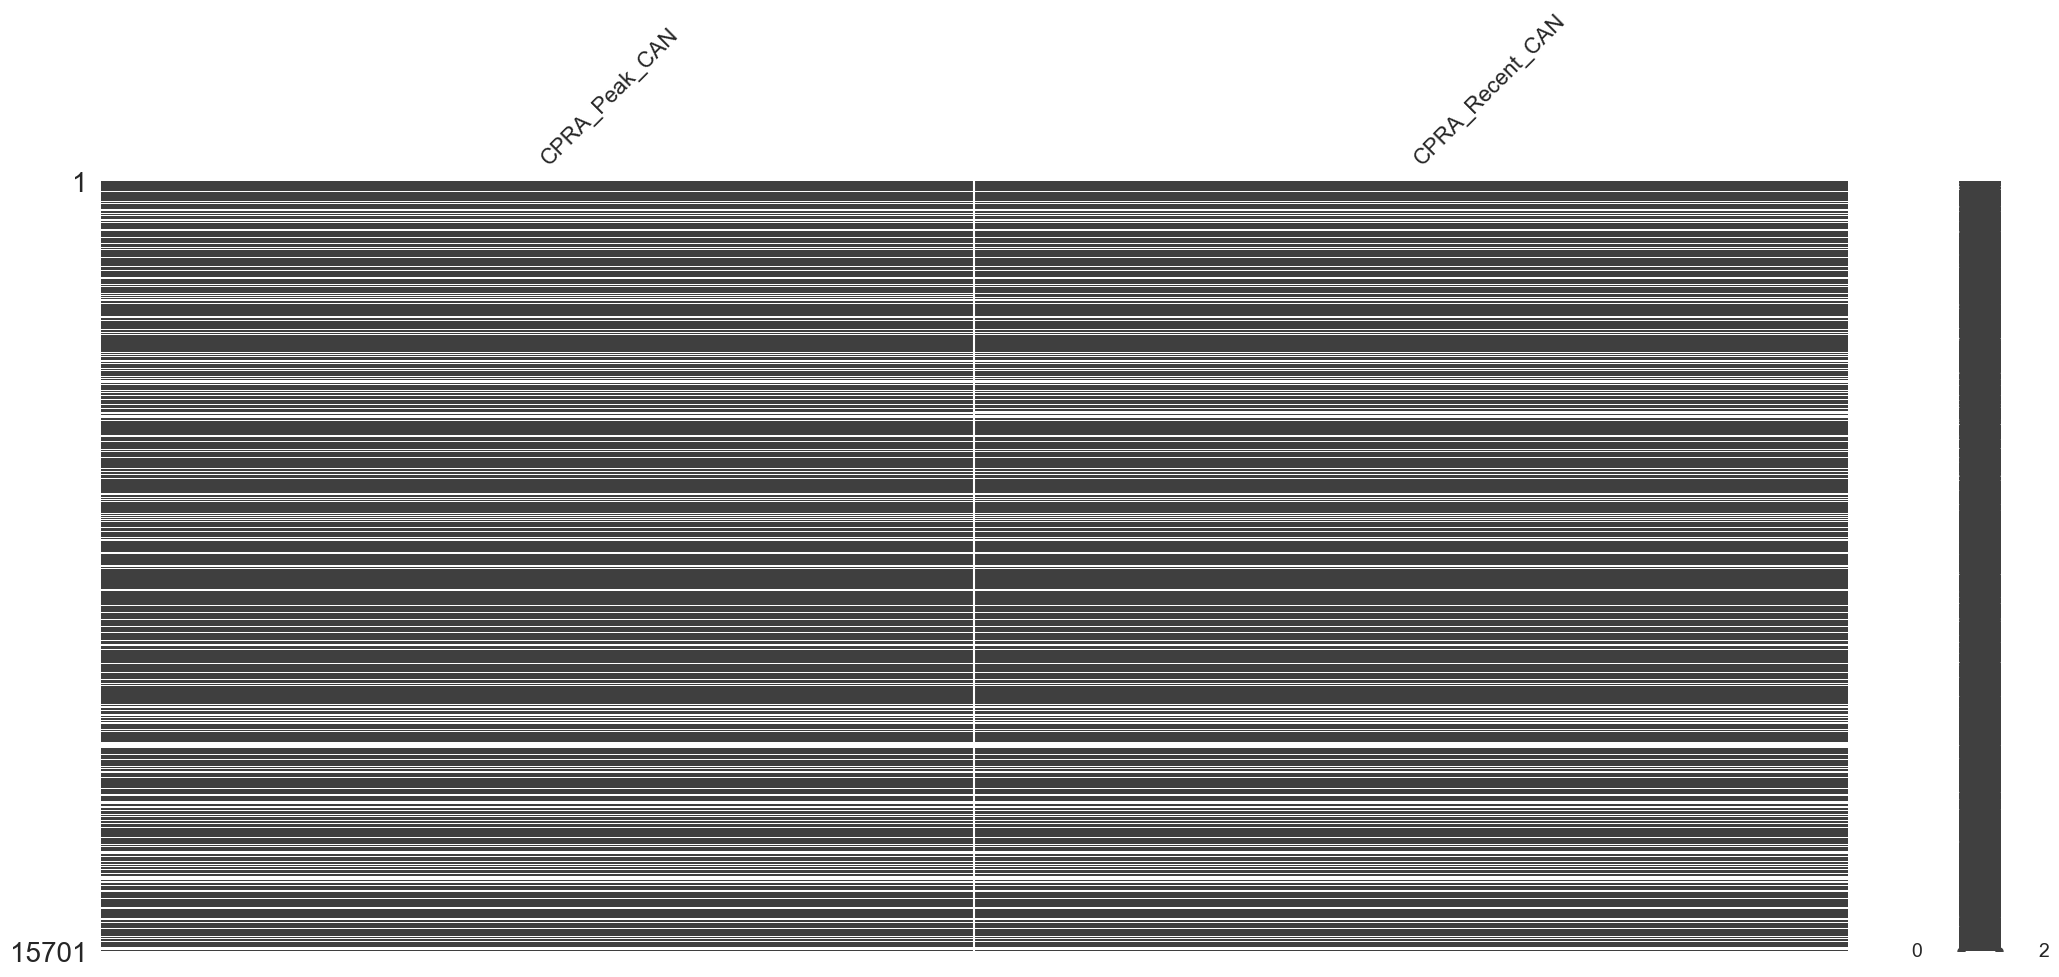

In [17]:
# plot missing data
uv.plotMissingData(df[features])

In [18]:
# hypothesis testing
usf.testMCAR(df[features])

Little's MCAR test p-value: 0.0001
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


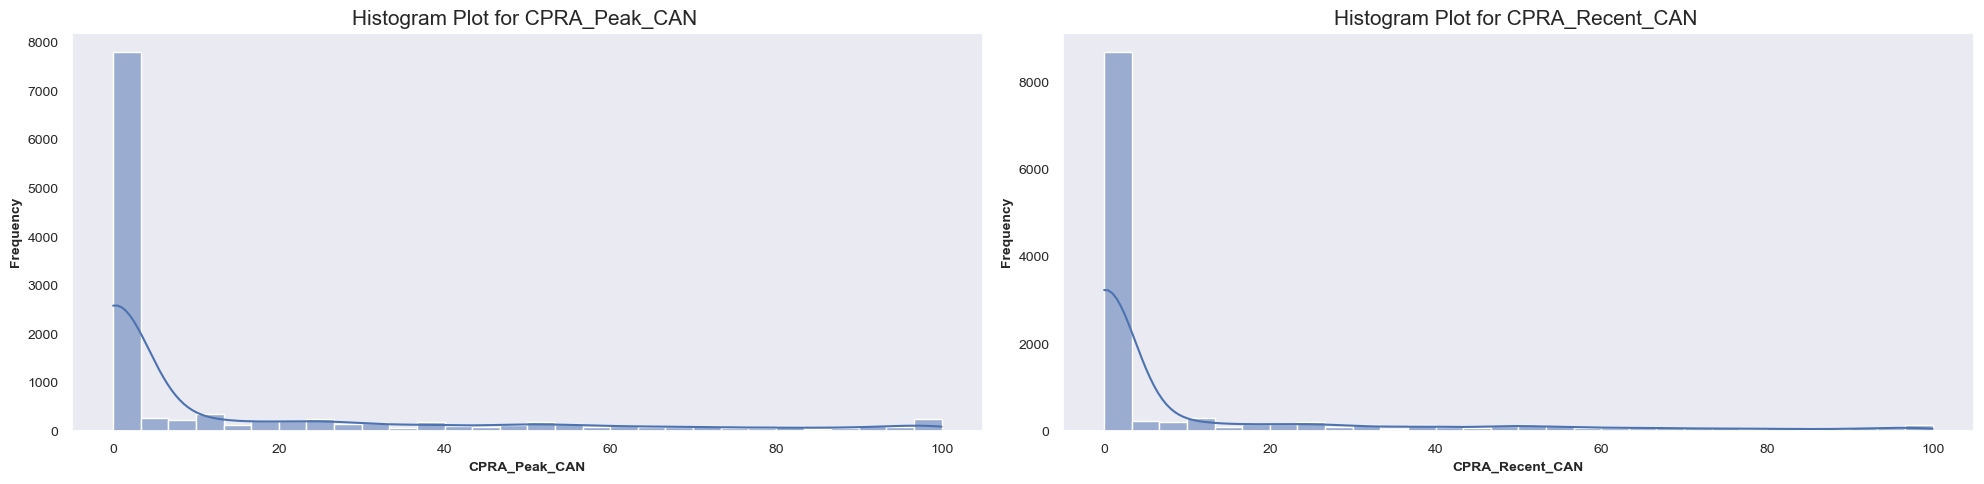

In [21]:
uv.histogramPlot(df, features, bins=30)

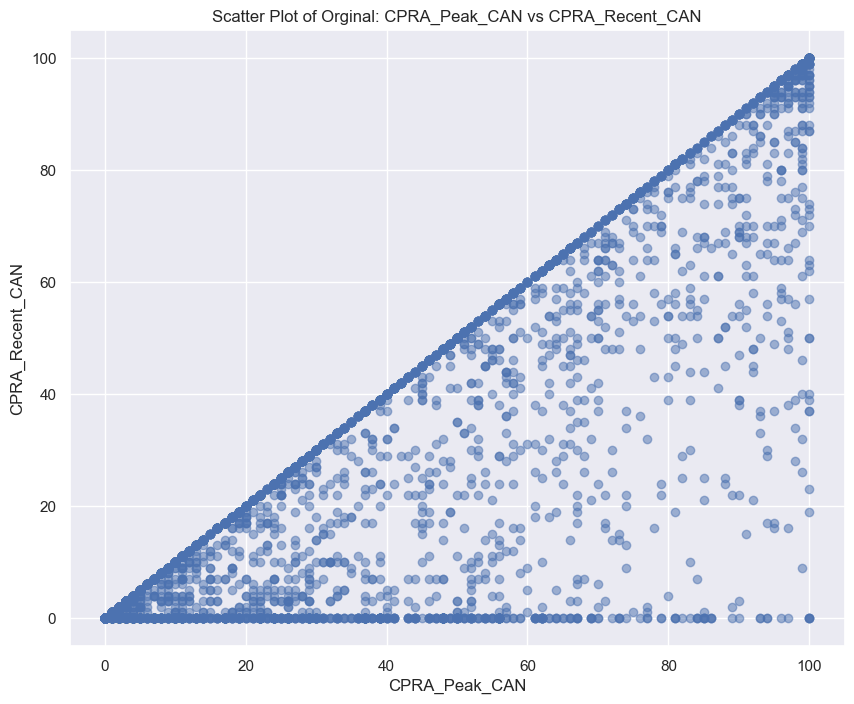

In [22]:
# scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(x=df['CPRA_Peak_CAN'], y=df['CPRA_Recent_CAN'], alpha=0.5)
plt.xlabel('CPRA_Peak_CAN')
plt.ylabel('CPRA_Recent_CAN')
plt.title('Scatter Plot of Orginal: CPRA_Peak_CAN vs CPRA_Recent_CAN')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression


# Split the data into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Placeholder for imputed labels
imputed_labels = train_data['label'].copy()

# K-fold cross-validation for label imputation on training data
for train_index, val_index in kf.split(train_data):
    train_fold = train_data.iloc[train_index]
    val_fold = train_data.iloc[val_index]
    
    # Separate features and labels
    X_train = train_fold.drop(columns='label')
    y_train = train_fold['label'].dropna()  # Drop missing labels for training
    X_train = X_train.loc[y_train.index]  # Align features with non-missing labels
    
    X_val = val_fold.drop(columns='label')
    
    # Train a model (e.g., Logistic Regression)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    # Predict missing labels in the validation fold
    missing_label_indices = val_fold['label'].isna()
    if missing_label_indices.any():
        imputed_labels[val_index[missing_label_indices]] = model.predict(X_val[missing_label_indices])

# Combine original training data with imputed labels
train_data['imputed_label'] = imputed_labels

# Train final model on the entire training set with imputed labels
final_model = LogisticRegression()
final_model.fit(train_data.drop(columns='label'), train_data['imputed_label'])

# Evaluate the model on the test data
X_test = test_data.drop(columns='label')
y_test = test_data['label']
test_predictions = final_model.predict(X_test)

print("Test Predictions:\n", test_predictions)

##### `GaussianMixture:` Impute missing values based on the learned distribution of the data, ensuring that the imputed values are consistent with the overall data structure.

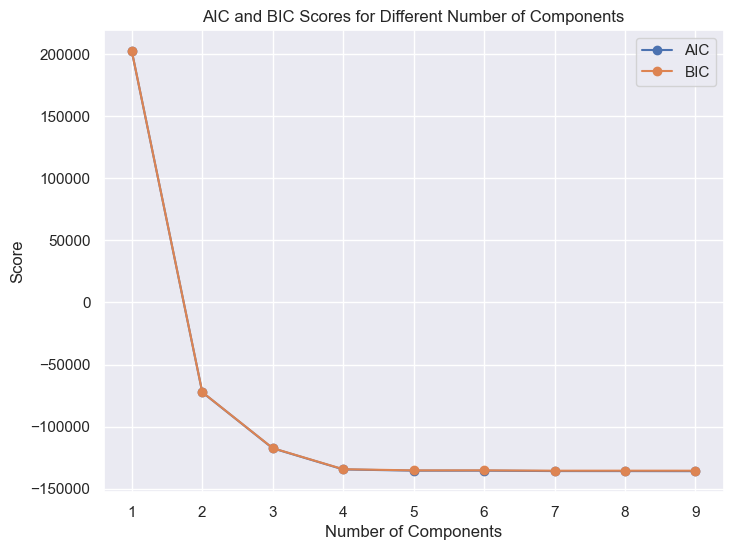

Optimal number of components: 7


In [23]:
ui.findGaussianMixtureComponents(df[features], RANDOM_STATE, component_range=range(1, 10), figsize=(8,6))

In [24]:
# impute
imputeGaussian = ui.imputeGaussianMixture(df[features], RANDOM_STATE, n_components=4, minimum=0, maximum=100)

# shape
print(f"Dataset Shape: {imputeGaussian.shape}")

Dataset Shape: (15701, 2)


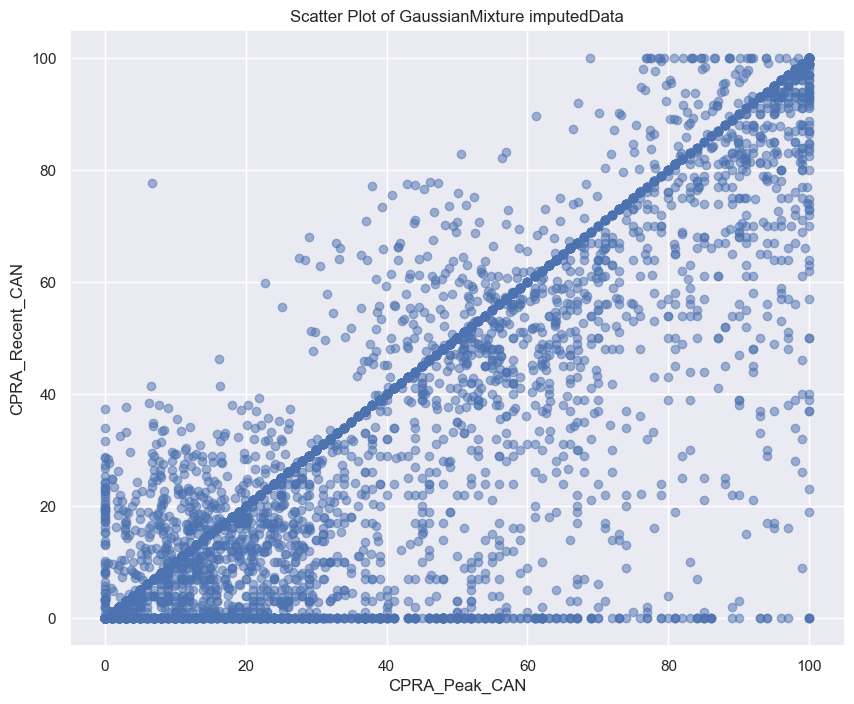

In [25]:
plt.figure(figsize=(10, 8))
plt.scatter(x=imputeGaussian['CPRA_Peak_CAN'], y=imputeGaussian['CPRA_Recent_CAN'], alpha=0.5)
plt.xlabel('CPRA_Peak_CAN')
plt.ylabel('CPRA_Recent_CAN')
plt.title('Scatter Plot of GaussianMixture imputedData')
plt.grid(True)
plt.show()

##### `KNN Impute:` Impute missing values in datasets using the k-Nearest Neighbors algorithm. 
- It replaces missing values with estimates based on similar data points in the dataset.
- For each sample with missing values, it finds the k nearest neighbors in the dataset.
    - It then imputes the missing value using the mean or weighted average of those neighbors' values.
- Preserves the original variable distribution.
- Does not assume any underlying data distribution.
- Can handle complex relationships in the data.
- KNN Imputation is a flexible and effective method for handling missing data, particularly when the relationships between variables are complex or non-linear.

The best n_neighbors for KNN imputer is: 7
The best weights for KNN imputer is: distance


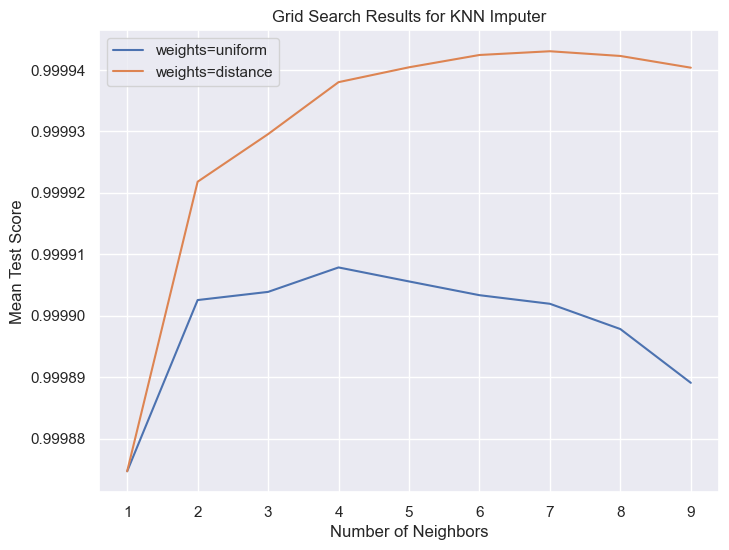

Dataset Shape: (15701, 2)


In [26]:
# impute
imputeKNN=ui.imputeKNN(df, ['CPRA_Peak_CAN','CPRA_Recent_CAN'])

# shape
print(f"Dataset Shape: {imputeKNN.shape}")

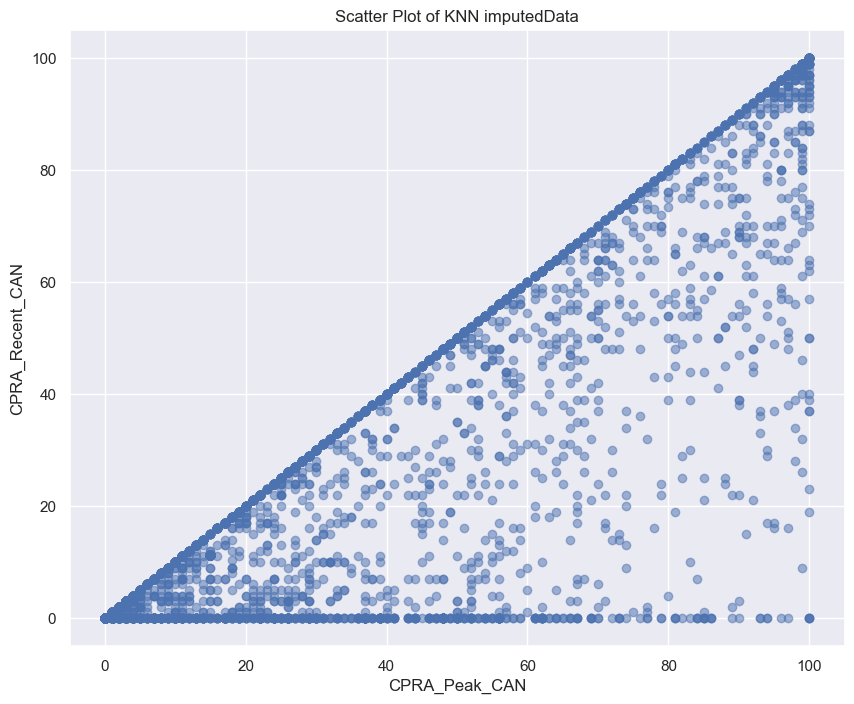

In [27]:
plt.figure(figsize=(10, 8))
plt.scatter(x=imputeKNN['CPRA_Peak_CAN'], y=imputeKNN['CPRA_Recent_CAN'], alpha=0.5)
plt.xlabel('CPRA_Peak_CAN')
plt.ylabel('CPRA_Recent_CAN')
plt.title('Scatter Plot of KNN imputedData')
plt.grid(True)
plt.show()

##### imputeKNN

In [30]:
# round
imputeKNN = np.floor(imputeKNN)

# update original dataframe with imputed dataframe values
df.update(imputeKNN)

# create new feature: add small constant to handle 0 values
df['PanelReactiveAntibody_CPRA_Interaction_CAN'] = (df.CPRA_Recent_CAN + 1e-5) * (df.CPRA_Peak_CAN + 1e-5)
# create new feature difference & addition between CPRA_Peak_CAN & CPRA_Recent_CAN
df['PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN'] = df.CPRA_Peak_CAN - df.CPRA_Recent_CAN
df['PanelReactiveAntibody_CPRA_Addition_CAN'] = df.CPRA_Peak_CAN + df.CPRA_Recent_CAN

#### Creatinine

In [31]:
# examine features
features = getFeatureList(df[result], 'Creatinine(?!_DON)')

                              count      mean       std   min   25%   50%  75%   max
CreatinineRegistration_CAN  16016.0  1.386274  1.011872  0.08  0.95  1.20  1.5  24.0
CreatinineTransplant_CAN    15708.0  1.379902  1.060986  0.06  0.94  1.19  1.5  37.0

:::: NaN Count:
CreatinineRegistration_CAN    110
CreatinineTransplant_CAN      418


In [32]:
df[features].corr()

,CreatinineRegistration_CAN,CreatinineTransplant_CAN
CreatinineRegistration_CAN,1.000000,0.690318
CreatinineTransplant_CAN,0.690318,1.000000


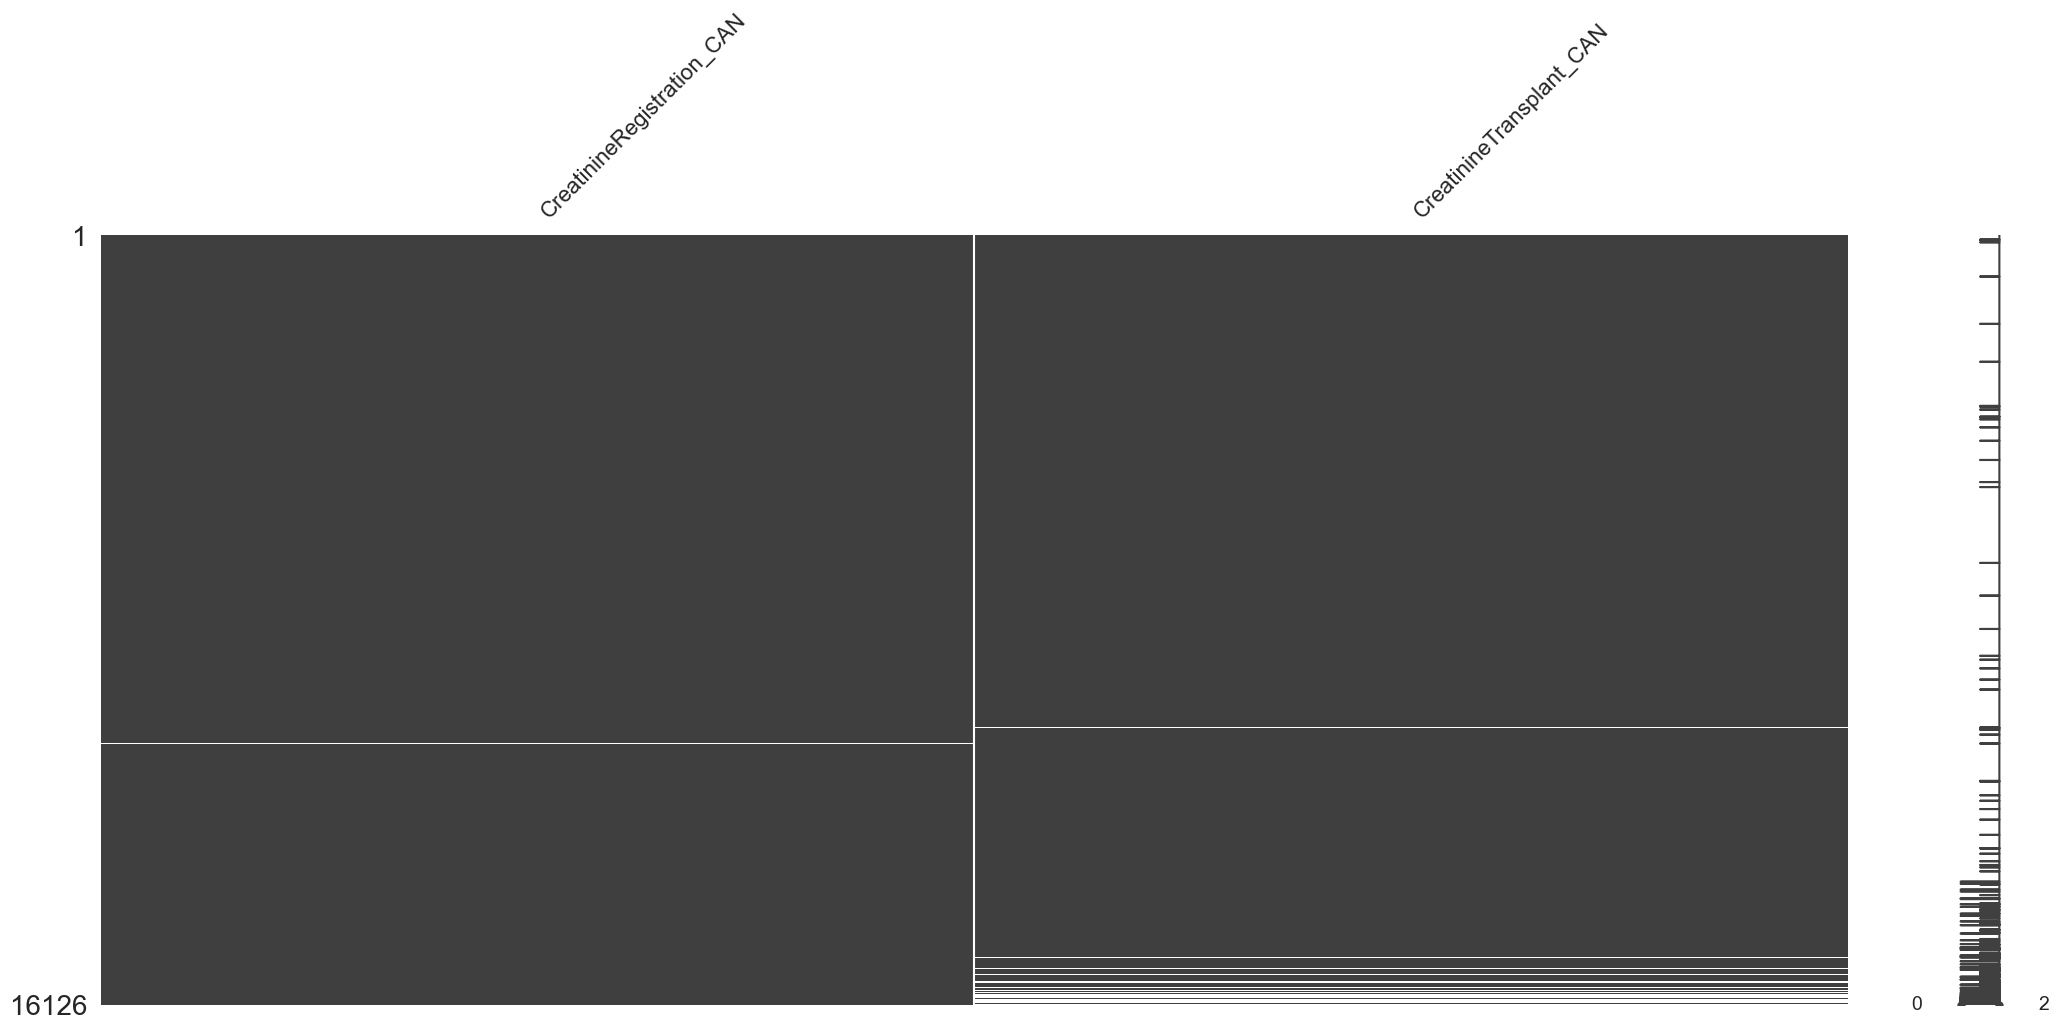

In [33]:
# plot missing data
uv.plotMissingData(df[features])

In [34]:
# hypothesis testing
usf.testMCAR(df[features])

Little's MCAR test p-value: 0.0700
Fail to reject null hypothesis: Data may be Missing Completely At Random (MCAR).


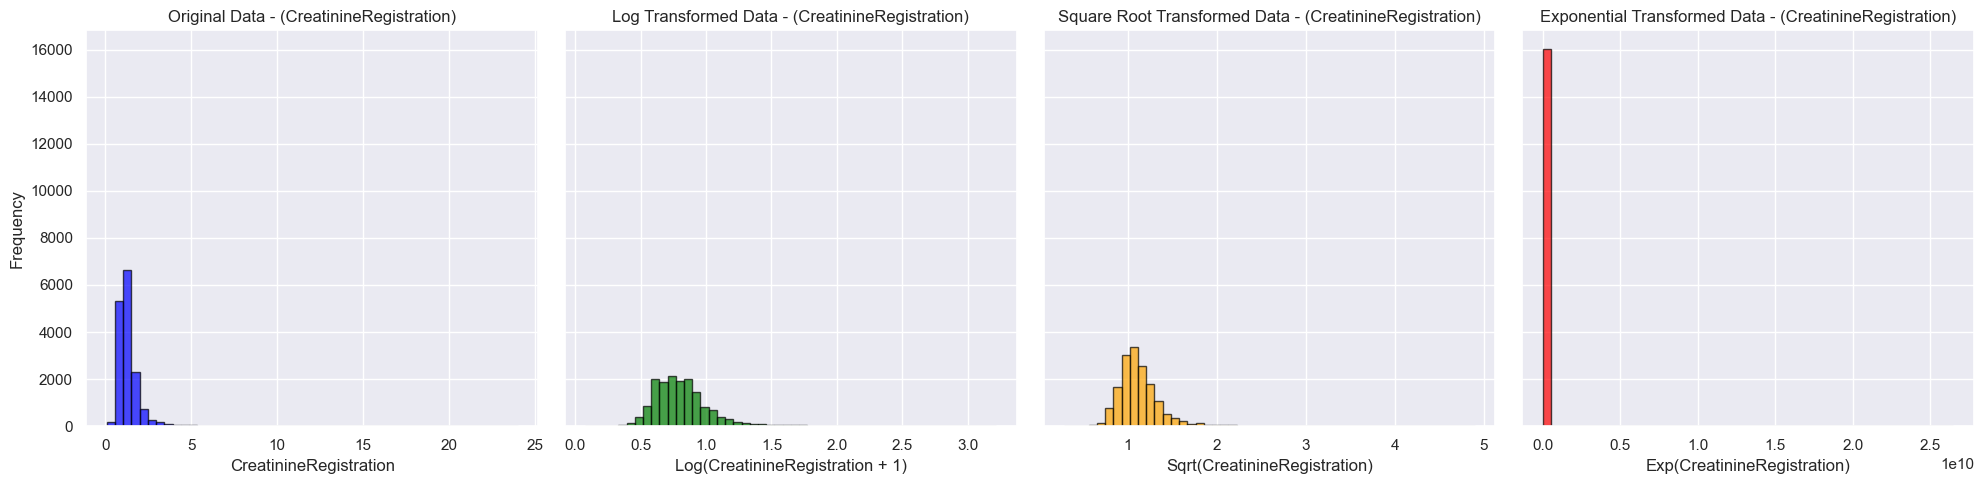

In [35]:
uv.transformPlots(df['CreatinineRegistration_CAN'], txt='CreatinineRegistration', bins=50)

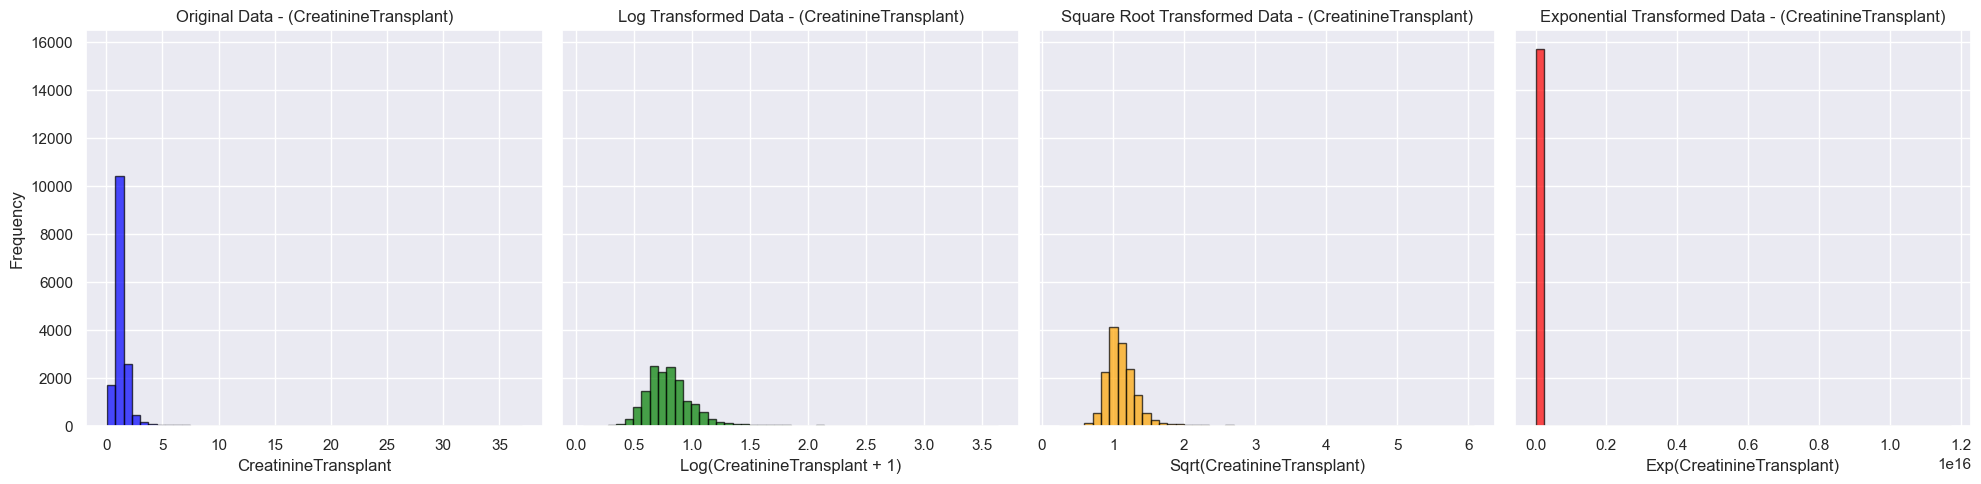

In [36]:
uv.transformPlots(df['CreatinineTransplant_CAN'], txt='CreatinineTransplant', bins=50)

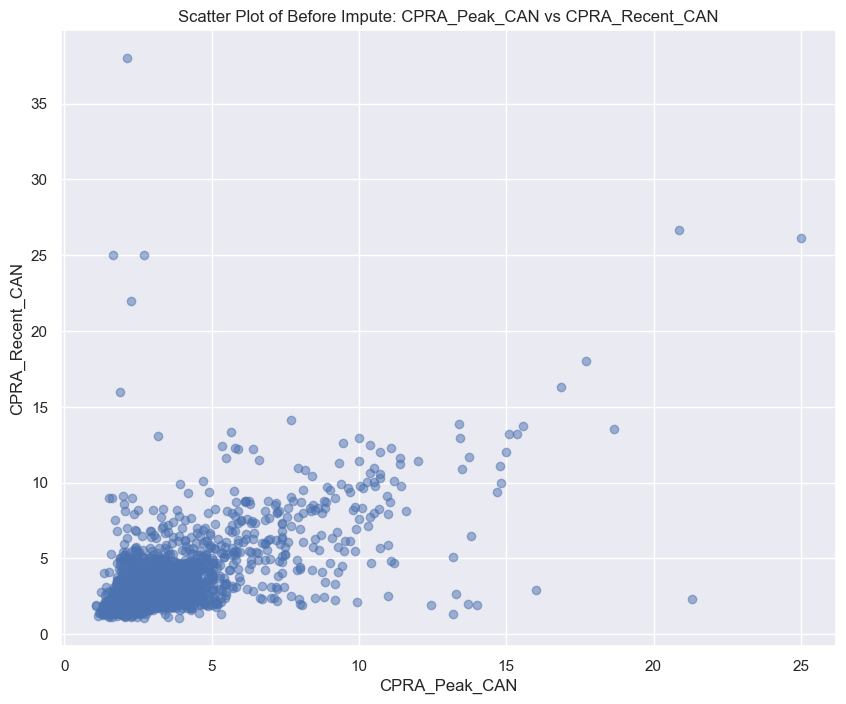

In [37]:
plt.figure(figsize=(10, 8))
plt.scatter(x=(df['CreatinineRegistration_CAN']+1), y=(df['CreatinineTransplant_CAN']+1), alpha=0.5)
plt.xlabel('CPRA_Peak_CAN')
plt.ylabel('CPRA_Recent_CAN')
plt.title('Scatter Plot of Before Impute: CPRA_Peak_CAN vs CPRA_Recent_CAN')
plt.grid(True)
plt.show()

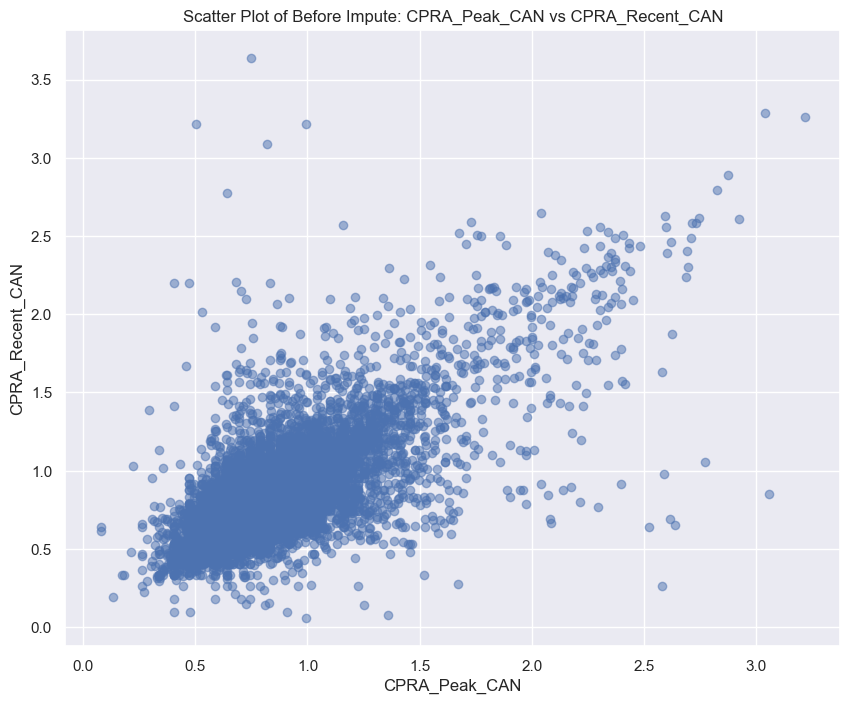

In [38]:
plt.figure(figsize=(10, 8))
plt.scatter(x=np.log(df['CreatinineRegistration_CAN']+1), y=np.log(df['CreatinineTransplant_CAN']+1), alpha=0.5)
plt.xlabel('CPRA_Peak_CAN')
plt.ylabel('CPRA_Recent_CAN')
plt.title('Scatter Plot of Before Impute: CPRA_Peak_CAN vs CPRA_Recent_CAN')
plt.grid(True)
plt.show()

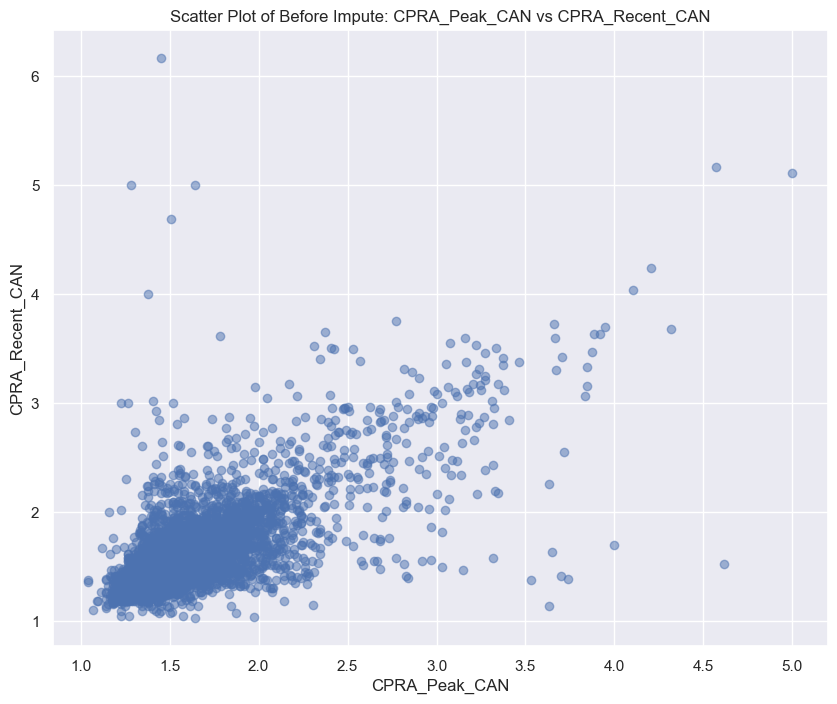

In [39]:
plt.figure(figsize=(10, 8))
plt.scatter(x=np.sqrt(df['CreatinineRegistration_CAN']+1), y=np.sqrt(df['CreatinineTransplant_CAN']+1), alpha=0.5)
plt.xlabel('CPRA_Peak_CAN')
plt.ylabel('CPRA_Recent_CAN')
plt.title('Scatter Plot of Before Impute: CPRA_Peak_CAN vs CPRA_Recent_CAN')
plt.grid(True)
plt.show()

### Save

In [40]:
# heart dataset: remove NaNs
uf.writeToFile(df_removeNaNs, 'Heart_ML_DropNaNs',path='../Data/', format='pkl')

# heart dataset
uf.writeToFile(df, 'Heart_ML_Orig',path='../Data/', format='pkl')


# heart label
uf.writeToFile(df_label, 'Label_ML',path='../Data/', format='pkl')

# heart candidate
uf.writeToFile(df_can, 'CAN_ML', format='pkl')

# heart donor
uf.writeToFile(df_don, 'DON_ML', format='pkl')

# heart both
uf.writeToFile(df_both, 'BOTH_ML', format='pkl')

# heart nominal
uf.writeToFile(df_nominal, 'Nominal_ML', format='pkl')

# heart ordinal
uf.writeToFile(df_ordinal, 'Ordinal_ML', format='pkl')

# heart numeric
uf.writeToFile(df_numeric, 'Numeric_ML', format='pkl')

# heart drop
uf.writeToFile(df_drop, 'Drop_ML', format='pkl')

# heart new
uf.writeToFile(df_new, 'New_ML', format='pkl')

# heart object
uf.writeToFile(df_object, 'Object_ML', format='pkl')

# heart unknown
uf.writeToFile(df_unknown, 'Unknown_ML', format='pkl')

# heart date
uf.writeToFile(df_date, 'Date_ML', format='pkl')

# heart data dictionary
uf.writeToFile(df_dict, 'Dictionary_ML', format='pkl')

9,850 records written to ../Data/Heart_ML_DropNaNs.pkl
16,126 records written to ../Data/Heart_ML_Orig.pkl
1 records written to ../Data/Label_ML.pkl
114 records written to ../Data/CAN_ML.pkl
88 records written to ../Data/DON_ML.pkl
22 records written to ../Data/BOTH_ML.pkl
166 records written to ../Data/Nominal_ML.pkl
12 records written to ../Data/Ordinal_ML.pkl
42 records written to ../Data/Numeric_ML.pkl
0 records written to ../Data/Drop_ML.pkl
29 records written to ../Data/New_ML.pkl
0 records written to ../Data/Object_ML.pkl
0 records written to ../Data/Unknown_ML.pkl
0 records written to ../Data/Date_ML.pkl
302 records written to ../Data/Dictionary_ML.pkl
